# SR / RRDB Checkpoint Visualizer

Notebook nay dung de inspect tung track trong test set:

- Hien thi 5 frame LR goc.
- Hien thi RRDB/SR output 2x.
- Hien thi anh SR sau khi downsample ve input size cua OCR.
- So sanh prediction, ground truth, confidence cua nhieu checkpoint.
- Tu dong chon ca case dung va sai, va luon include `track_10119`.

Cac checkpoint duoc so sanh gom baseline no-SR, SR v4 joint, SR v7 feed-HR,
SR fix e1, va checkpoint ghep RRDB v4 + OCR baseline.

In [1]:
from pathlib import Path
import os
import sys
import glob
import json
import random
from collections import OrderedDict

import cv2
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = Path.cwd()
if not (ROOT / "configs").exists():
    ROOT = ROOT.parent
os.chdir(ROOT)
sys.path.insert(0, str(ROOT))

from configs.config import Config
from src.data.transforms import get_val_transforms
from src.models.restran import ResTranOCR
from src.utils.common import seed_everything
from src.utils.postprocess import decode_with_confidence

seed_everything(42)
cfg = Config()
NUM_FRAMES = getattr(cfg, "NUM_FRAMES", 5)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("ROOT:", ROOT)
print("DEVICE:", DEVICE)
print("NUM_FRAMES:", NUM_FRAMES)

Deterministic mode ENABLED (reproducibility optimized). Benchmark mode DISABLED.
ROOT: c:\Users\OS\Downloads\ICPR-2026\MultiFrame-LPR
DEVICE: cuda
NUM_FRAMES: 5


## 1. Checkpoint registry

`sr_v4_rrdb_plus_baseline_73.03` la checkpoint tot nhat hien tai:

- RRDB weights lay tu `restran_sr_v4_best.pth`
- OCR weights lay tu baseline `restran_best.pth`
- Test accuracy da do: `73.03%`

`sr_v7_feedhr_joint_62.23` la checkpoint dang mo trong tab cua ban,
test accuracy da do: `62.23%`.

In [2]:
CHECKPOINTS = OrderedDict({
    "baseline_no_sr_73.00": {
        "path": "results/restran_best.pth",
        "csv": "results/test_predictions_restran.csv",
        "use_sr": False,
        "sr_feed_hr": False,
        "sr_blend": 0.0,
        "note": "ResTranOCR baseline, no SR",
    },
    "sr_v4_rrdb_plus_baseline_73.03": {
        "path": "results/restran_baseline_ocr_v4_sr_best.pth",
        "csv": "results/test_predictions_restran_baseline_ocr_v4_sr_unclamped.csv",
        "use_sr": True,
        "sr_feed_hr": False,
        "sr_blend": 1.0,
        "note": "RRDB from v4 + OCR baseline; best measured SR pipeline",
    },
    "sr_v4_joint_72.47": {
        "path": "results/restran_sr_v4_best.pth",
        "csv": "results/test_predictions_restran_sr_v4_cpu.csv",
        "use_sr": True,
        "sr_feed_hr": False,
        "sr_blend": 1.0,
        "note": "Joint-trained RRDB + OCR from v4",
    },
    "sr_v7_feedhr_joint_62.23": {
        "path": "results/restran_sr_v7_best.pth",
        "csv": "results/test_predictions_restran_sr_v7_rerun.csv",
        "use_sr": True,
        "sr_feed_hr": True,
        "sr_blend": 1.0,
        "note": "v7 feed-HR joint checkpoint; low test accuracy",
    },
    "sr_fix_e1_72.57": {
        "path": "results/restran_sr_fix_e1_best.pth",
        "csv": "results/test_predictions_restran_sr_fix_e1.csv",
        "use_sr": True,
        "sr_feed_hr": False,
        "sr_blend": 1.0,
        "note": "1 epoch SR-only fine-tune from merged checkpoint",
    },
})

SR_MODEL_NAMES = [name for name, spec in CHECKPOINTS.items() if spec["use_sr"]]

for name, spec in CHECKPOINTS.items():
    print(f"{name:36s}", Path(spec["path"]).exists(), spec["note"])

baseline_no_sr_73.00                 True ResTranOCR baseline, no SR
sr_v4_rrdb_plus_baseline_73.03       True RRDB from v4 + OCR baseline; best measured SR pipeline
sr_v4_joint_72.47                    True Joint-trained RRDB + OCR from v4
sr_v7_feedhr_joint_62.23             True v7 feed-HR joint checkpoint; low test accuracy
sr_fix_e1_72.57                      True 1 epoch SR-only fine-tune from merged checkpoint


## 2. Read prediction CSVs and pick representative test tracks

In [3]:
def read_pred_csv(path):
    path = Path(path)
    if not path.exists():
        return pd.DataFrame(
            columns=["track_id", "prediction", "confidence", "ground_truth", "correct"]
        )
    df = pd.read_csv(path)
    df["track_id"] = df["track_id"].astype(str)
    df["prediction"] = df["prediction"].astype(str)
    df["ground_truth"] = df["ground_truth"].astype(str)
    df["correct"] = df["correct"].astype(int)
    return df


pred_tables = {name: read_pred_csv(spec["csv"]) for name, spec in CHECKPOINTS.items()}

summary = []
for name, df in pred_tables.items():
    correct = int(df["correct"].sum()) if len(df) else None
    total = len(df) if len(df) else None
    acc = 100.0 * correct / total if total else None
    summary.append((name, correct, total, acc, CHECKPOINTS[name]["note"]))

summary_df = pd.DataFrame(
    summary,
    columns=["checkpoint", "correct", "total", "acc_percent", "note"],
)
display(summary_df)

,checkpoint,correct,total,acc_percent,note
0,baseline_no_sr_73.00,2190,3000,73.000000,"ResTranOCR baseline, no SR"
1,sr_v4_rrdb_plus_baseline_73.03,2191,3000,73.033333,RRDB from v4 + OCR baseline; best measured SR ...
2,sr_v4_joint_72.47,2174,3000,72.466667,Joint-trained RRDB + OCR from v4
3,sr_v7_feedhr_joint_62.23,1867,3000,62.233333,v7 feed-HR joint checkpoint; low test accuracy
4,sr_fix_e1_72.57,2177,3000,72.566667,1 epoch SR-only fine-tune from merged checkpoint


In [4]:
base = pred_tables["baseline_no_sr_73.00"].set_index("track_id")
best = pred_tables["sr_v4_rrdb_plus_baseline_73.03"].set_index("track_id")
v7 = pred_tables["sr_v7_feedhr_joint_62.23"].set_index("track_id")

all_ids = sorted(set(base.index) & set(best.index) & set(v7.index))
cases = pd.DataFrame({
    "track_id": all_ids,
    "gt": [base.loc[t, "ground_truth"] for t in all_ids],
    "base_pred": [base.loc[t, "prediction"] for t in all_ids],
    "base_ok": [int(base.loc[t, "correct"]) for t in all_ids],
    "best_sr_pred": [best.loc[t, "prediction"] for t in all_ids],
    "best_sr_ok": [int(best.loc[t, "correct"]) for t in all_ids],
    "v7_pred": [v7.loc[t, "prediction"] for t in all_ids],
    "v7_ok": [int(v7.loc[t, "correct"]) for t in all_ids],
})


def take_ids(mask, n, seed=42):
    pool = cases.loc[mask, "track_id"].tolist()
    rng = random.Random(seed)
    rng.shuffle(pool)
    return pool[:n]


selected_ids = []
selected_ids += ["track_10119"]
selected_ids += take_ids((cases.base_ok == 0) & (cases.best_sr_ok == 1), 4, seed=1)
selected_ids += take_ids((cases.base_ok == 1) & (cases.best_sr_ok == 0), 4, seed=2)
selected_ids += take_ids((cases.v7_ok == 0) & (cases.best_sr_ok == 1), 4, seed=3)
selected_ids += take_ids(
    (cases.base_ok == 1) & (cases.best_sr_ok == 1) & (cases.v7_ok == 1),
    4,
    seed=4,
)
selected_ids += take_ids(
    (cases.base_ok == 0) & (cases.best_sr_ok == 0) & (cases.v7_ok == 0),
    4,
    seed=5,
)
selected_ids = list(OrderedDict.fromkeys([t for t in selected_ids if t in all_ids]))


def case_bucket(row):
    if row.base_ok == 0 and row.best_sr_ok == 1:
        return "best_sr_fixes_baseline"
    if row.base_ok == 1 and row.best_sr_ok == 0:
        return "best_sr_breaks_baseline"
    if row.v7_ok == 0 and row.best_sr_ok == 1:
        return "v7_fails_best_sr_ok"
    if row.base_ok == 1 and row.best_sr_ok == 1 and row.v7_ok == 1:
        return "all_correct"
    if row.base_ok == 0 and row.best_sr_ok == 0 and row.v7_ok == 0:
        return "all_wrong"
    return "mixed"


cases["bucket"] = cases.apply(case_bucket, axis=1)
display(cases[cases.track_id.isin(selected_ids)])
print("Selected tracks:", selected_ids)

,track_id,gt,base_pred,base_ok,best_sr_pred,best_sr_ok,v7_pred,v7_ok,bucket
34,track_10119,BAF9394,BAF5354,0,BAF5354,0,BAF5354,0,all_wrong
141,track_10598,BAL0730,BAL0730,1,BAL0730,1,BAL0738,0,v7_fails_best_sr_ok
172,track_10768,QHL1343,QHL1343,1,QHL1343,1,OML1343,0,v7_fails_best_sr_ok
199,track_10860,AWE6671,AWE4621,0,AWE4621,0,AWL4627,0,all_wrong
523,track_12319,AKF3618,AKY9418,0,AKY9418,0,AKI0418,0,all_wrong
566,track_12471,ABL3656,ABL3658,0,ABL3656,1,ABL3658,0,best_sr_fixes_baseline
1058,track_14544,AYP5I57,AYP5I57,1,AYP5I57,1,AYP5I57,1,all_correct
1211,track_15149,QQC0D18,QQC0D18,1,QQC0D18,1,QQC0B18,0,v7_fails_best_sr_ok
1393,track_15824,BEW9H92,BEV9H92,0,BEW9H92,1,BEW9H92,1,best_sr_fixes_baseline
1429,track_16025,SEM6C72,SEM6C72,1,SEH6C72,0,SEM6C72,1,best_sr_breaks_baseline


Selected tracks: ['track_10119', 'track_15824', 'track_12471', 'track_19947', 'track_21729', 'track_21218', 'track_19767', 'track_16025', 'track_22671', 'track_10598', 'track_10768', 'track_15149', 'track_18599', 'track_20634', 'track_14544', 'track_16720', 'track_16334', 'track_12319', 'track_10860', 'track_16638', 'track_20850']


## 3. Model loading and image helpers

In [5]:
MEAN = torch.tensor([0.485, 0.456, 0.406])
STD = torch.tensor([0.229, 0.224, 0.225])
VAL_TRANSFORM = get_val_transforms(cfg.IMG_HEIGHT, cfg.IMG_WIDTH)
model_cache = {}


def build_model(spec):
    model = ResTranOCR(
        num_classes=cfg.NUM_CLASSES,
        transformer_heads=cfg.TRANSFORMER_HEADS,
        transformer_layers=cfg.TRANSFORMER_LAYERS,
        transformer_ff_dim=cfg.TRANSFORMER_FF_DIM,
        dropout=cfg.TRANSFORMER_DROPOUT,
        use_stn=cfg.USE_STN,
        pretrained=False,
        use_sr=spec["use_sr"],
        sr_num_blocks=getattr(cfg, "SR_NUM_BLOCKS", 8),
        sr_scale=getattr(cfg, "SR_SCALE", 2),
        sr_nf=getattr(cfg, "SR_NF", 32),
        sr_gc=getattr(cfg, "SR_GC", 16),
        sr_feed_hr=spec["sr_feed_hr"],
        sr_blend=spec["sr_blend"],
        sr_use_checkpoint=False,
    )
    return model.to(DEVICE)


def load_state_dict(path):
    state = torch.load(path, map_location=DEVICE)
    if isinstance(state, dict) and "model_state_dict" in state:
        state = state["model_state_dict"]
    if isinstance(state, dict) and any(k.startswith("module.") for k in state.keys()):
        state = {k.replace("module.", "", 1): v for k, v in state.items()}
    return state


def get_model(name):
    if name not in model_cache:
        spec = CHECKPOINTS[name]
        model = build_model(spec)
        state = load_state_dict(spec["path"])
        missing, unexpected = model.load_state_dict(state, strict=False)
        model.eval()
        model_cache[name] = model
        print(f"loaded {name}: missing={len(missing)}, unexpected={len(unexpected)}")
    return model_cache[name]


def track_path(track_id):
    direct = Path(cfg.TEST_DATA_ROOT) / track_id
    if direct.exists():
        return direct
    matches = list(Path(cfg.TEST_DATA_ROOT).rglob(track_id))
    if not matches:
        raise FileNotFoundError(track_id)
    return matches[0]


def read_label(track_dir):
    with open(Path(track_dir) / "annotations.json", encoding="utf-8") as f:
        data = json.load(f)
    if isinstance(data, list):
        data = data[0] if data else {}
    return str(data.get("plate_text") or data.get("license_plate") or data.get("text") or "").strip().upper()


def image_files(track_dir, prefix="lr"):
    files = []
    for ext in ("png", "jpg", "jpeg"):
        files.extend(glob.glob(str(Path(track_dir) / f"{prefix}-*.{ext}")))
    files = sorted(files)
    if not files:
        raise FileNotFoundError(f"No {prefix}-*.png/jpg/jpeg files in {track_dir}")
    if len(files) >= NUM_FRAMES:
        return files[:NUM_FRAMES]
    return files + [files[-1]] * (NUM_FRAMES - len(files))


def load_raw_frames(track_id, prefix="lr"):
    files = image_files(track_path(track_id), prefix=prefix)
    frames = []
    for file in files:
        img = cv2.imread(file, cv2.IMREAD_COLOR)
        if img is None:
            raise ValueError(f"Could not read {file}")
        frames.append(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    return frames


def pad_frames_like_dataset(frames):
    max_h = max(img.shape[0] for img in frames)
    max_w = max(img.shape[1] for img in frames)
    padded = []
    for img in frames:
        h, w = img.shape[:2]
        if h != max_h or w != max_w:
            img = cv2.copyMakeBorder(
                img,
                0,
                max_h - h,
                0,
                max_w - w,
                cv2.BORDER_REPLICATE,
            )
        padded.append(img)
    return padded


def preprocess_frames(frames):
    padded = pad_frames_like_dataset(frames)
    transformed = VAL_TRANSFORM(
        image=padded[0],
        image1=padded[1],
        image2=padded[2],
        image3=padded[3],
        image4=padded[4],
    )
    x = torch.stack(
        [
            transformed["image"],
            transformed["image1"],
            transformed["image2"],
            transformed["image3"],
            transformed["image4"],
        ],
        dim=0,
    ).unsqueeze(0)
    resized_lr = [cv2.resize(img, (cfg.IMG_WIDTH, cfg.IMG_HEIGHT), interpolation=cv2.INTER_LINEAR) for img in padded]
    return x, resized_lr


def tensor_to_rgb(x):
    x = x.detach().float().cpu().permute(1, 2, 0).numpy()
    return np.clip(x, 0.0, 1.0)


def normalized_tensor_to_rgb(x):
    x = x.detach().float().cpu()
    x = x * STD.view(3, 1, 1) + MEAN.view(3, 1, 1)
    return tensor_to_rgb(x)

In [6]:
def predict_one(model_name, x):
    model = get_model(model_name)
    with torch.no_grad():
        logits = model(x.to(DEVICE))
    pred, conf = decode_with_confidence(logits, cfg.IDX2CHAR)[0]
    return pred, float(conf)


def rrdb_visuals(model_name, x):
    model = get_model(model_name)
    if not getattr(model, "use_sr", False):
        return None
    with torch.no_grad():
        _, sr = model(x.to(DEVICE), return_sr=True)
    sr_lr = F.interpolate(sr, size=(cfg.IMG_HEIGHT, cfg.IMG_WIDTH), mode="bilinear", align_corners=False)
    return {
        "sr_hr": [tensor_to_rgb(sr[i]) for i in range(sr.shape[0])],
        "sr_down_for_ocr": [tensor_to_rgb(sr_lr[i]) for i in range(sr_lr.shape[0])],
    }

## 4. Prediction and visualization functions

In [7]:
def prediction_table(track_id):
    rows = []
    for name, spec in CHECKPOINTS.items():
        df = pred_tables.get(name, pd.DataFrame())
        if len(df) and track_id in set(df["track_id"]):
            r = df[df["track_id"] == track_id].iloc[0]
            rows.append({
                "checkpoint": name,
                "prediction_csv": r["prediction"],
                "confidence_csv": float(r["confidence"]),
                "ground_truth": r["ground_truth"],
                "correct_csv": int(r["correct"]),
                "note": spec["note"],
            })
        else:
            rows.append({
                "checkpoint": name,
                "prediction_csv": None,
                "confidence_csv": None,
                "ground_truth": read_label(track_path(track_id)),
                "correct_csv": None,
                "note": spec["note"],
            })
    return pd.DataFrame(rows)


def run_live_predictions(track_id):
    frames = load_raw_frames(track_id)
    x, _ = preprocess_frames(frames)
    gt = read_label(track_path(track_id))
    rows = []
    for name, spec in CHECKPOINTS.items():
        pred, conf = predict_one(name, x)
        rows.append({
            "checkpoint": name,
            "live_prediction": pred,
            "live_confidence": conf,
            "ground_truth": gt,
            "live_correct": int(pred == gt),
            "note": spec["note"],
        })
    return pd.DataFrame(rows)


def show_frame_strip(images, title, cmap=None, figsize=(16, 2.6)):
    fig, axes = plt.subplots(1, len(images), figsize=figsize)
    fig.suptitle(title, y=1.08, fontsize=13)
    if len(images) == 1:
        axes = [axes]
    for i, (ax, img) in enumerate(zip(axes, images), start=1):
        ax.imshow(img, cmap=cmap)
        ax.set_title(f"frame {i}")
        ax.axis("off")
    plt.show()


def show_diff_strip(a_images, b_images, title, figsize=(16, 2.6)):
    diffs = []
    for a, b in zip(a_images, b_images):
        a = cv2.resize(a, (b.shape[1], b.shape[0])).astype(np.float32) / 255.0
        b = b.astype(np.float32)
        diffs.append(np.abs(b - a).mean(axis=2))
    show_frame_strip(diffs, title, cmap="magma", figsize=figsize)


def show_model_grid(rows_by_model, title, figsize=None):
    n_rows = len(rows_by_model)
    n_cols = NUM_FRAMES
    if figsize is None:
        figsize = (17, max(2.6, 2.5 * n_rows))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    if n_rows == 1:
        axes = np.expand_dims(axes, 0)
    fig.suptitle(title, y=1.01, fontsize=13)
    for r, (name, images) in enumerate(rows_by_model.items()):
        for c, img in enumerate(images):
            axes[r, c].imshow(img)
            axes[r, c].set_title(f"{name}\nf{c + 1}", fontsize=9)
            axes[r, c].axis("off")
    fig.tight_layout()
    plt.show()

In [8]:
def visualize_rrdb_grid(track_id, model_names=None):
    model_names = model_names or SR_MODEL_NAMES
    raw = load_raw_frames(track_id)
    x, resized_lr = preprocess_frames(raw)

    hr_rows = OrderedDict()
    down_rows = OrderedDict()
    for name in model_names:
        visuals = rrdb_visuals(name, x)
        if visuals is None:
            continue
        hr_rows[name] = visuals["sr_hr"]
        down_rows[name] = visuals["sr_down_for_ocr"]

    show_frame_strip(resized_lr, f"{track_id}: LR resized to OCR input 32x128", figsize=(16, 2.3))
    show_model_grid(hr_rows, f"{track_id}: RRDB output HR 64x256 for each SR checkpoint")
    show_model_grid(down_rows, f"{track_id}: SR downsampled to 32x128 for OCR")


def visualize_track(track_id, sr_model_name="sr_v4_rrdb_plus_baseline_73.03", show_all_rrdb=False):
    print("=" * 120)
    print("TRACK:", track_id)
    print("GT:", read_label(track_path(track_id)))

    display(prediction_table(track_id))
    live = run_live_predictions(track_id)
    display(live)

    raw = load_raw_frames(track_id)
    x, resized_lr = preprocess_frames(raw)

    show_frame_strip(raw, "Original raw LR frames from test track", figsize=(16, 2.3))
    show_frame_strip(resized_lr, "LR frames resized to OCR input 32x128", figsize=(16, 2.3))

    visuals = rrdb_visuals(sr_model_name, x)
    if visuals is not None:
        show_frame_strip(visuals["sr_hr"], f"{sr_model_name}: RRDB output HR 64x256", figsize=(16, 3.2))
        show_frame_strip(visuals["sr_down_for_ocr"], f"{sr_model_name}: SR downsampled back to 32x128 for OCR", figsize=(16, 2.3))
        show_diff_strip(resized_lr, visuals["sr_down_for_ocr"], f"{sr_model_name}: mean absolute visual difference vs resized LR")

    if show_all_rrdb:
        visualize_rrdb_grid(track_id)

## 5. Visualize selected correct/wrong cases

Cell nay visualize nhieu case. Neu GPU memory thieu, giam `selected_ids[:16]`
xuong `selected_ids[:5]`, hoac restart kernel roi chay tung `visualize_track("track_xxxxx")`.

Selected tracks: ['track_10119', 'track_15824', 'track_12471', 'track_19947', 'track_21729', 'track_21218', 'track_19767', 'track_16025', 'track_22671', 'track_10598', 'track_10768', 'track_15149', 'track_18599', 'track_20634', 'track_14544', 'track_16720', 'track_16334', 'track_12319', 'track_10860', 'track_16638', 'track_20850']
TRACK: track_10119
GT: BAF9394


,checkpoint,prediction_csv,confidence_csv,ground_truth,correct_csv,note
0,baseline_no_sr_73.00,BAF5354,0.9690,BAF9394,0,"ResTranOCR baseline, no SR"
1,sr_v4_rrdb_plus_baseline_73.03,BAF5354,0.9704,BAF9394,0,RRDB from v4 + OCR baseline; best measured SR ...
2,sr_v4_joint_72.47,BAF5354,0.9825,BAF9394,0,Joint-trained RRDB + OCR from v4
3,sr_v7_feedhr_joint_62.23,BAF5354,0.7425,BAF9394,0,v7 feed-HR joint checkpoint; low test accuracy
4,sr_fix_e1_72.57,BAF5354,0.9778,BAF9394,0,1 epoch SR-only fine-tune from merged checkpoint


loaded baseline_no_sr_73.00: missing=0, unexpected=0
loaded sr_v4_rrdb_plus_baseline_73.03: missing=0, unexpected=0
loaded sr_v4_joint_72.47: missing=0, unexpected=0
loaded sr_v7_feedhr_joint_62.23: missing=0, unexpected=0
loaded sr_fix_e1_72.57: missing=0, unexpected=0


,checkpoint,live_prediction,live_confidence,ground_truth,live_correct,note
0,baseline_no_sr_73.00,BAF5354,0.969003,BAF9394,0,"ResTranOCR baseline, no SR"
1,sr_v4_rrdb_plus_baseline_73.03,BAF5354,0.970371,BAF9394,0,RRDB from v4 + OCR baseline; best measured SR ...
2,sr_v4_joint_72.47,BAF5354,0.982412,BAF9394,0,Joint-trained RRDB + OCR from v4
3,sr_v7_feedhr_joint_62.23,BAF5354,0.742533,BAF9394,0,v7 feed-HR joint checkpoint; low test accuracy
4,sr_fix_e1_72.57,BAF5354,0.977827,BAF9394,0,1 epoch SR-only fine-tune from merged checkpoint


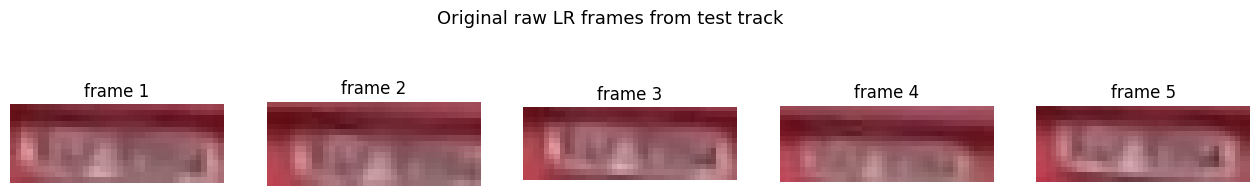

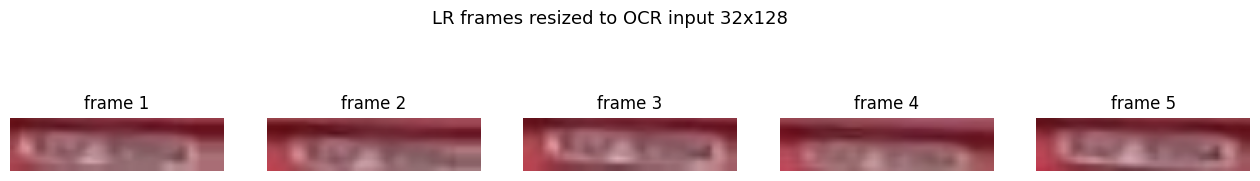

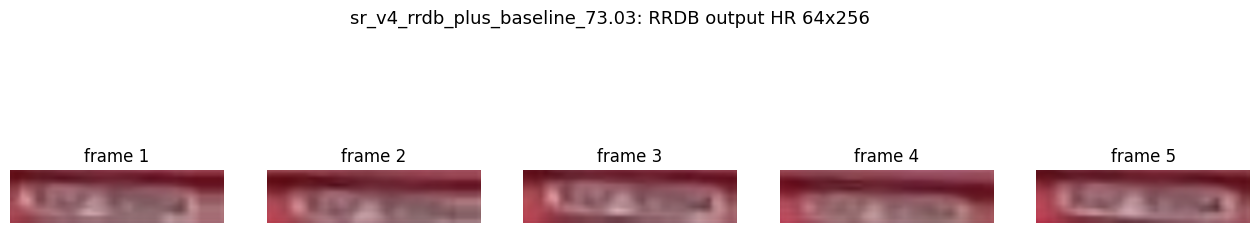

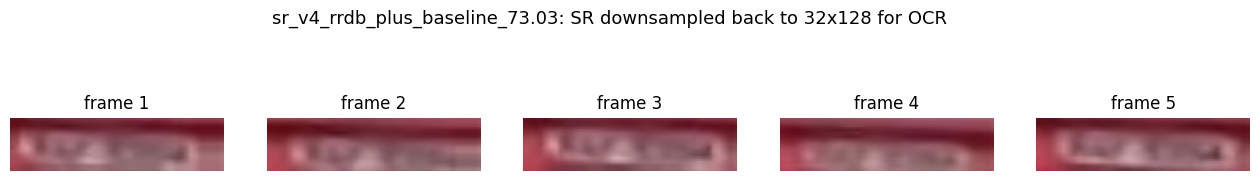

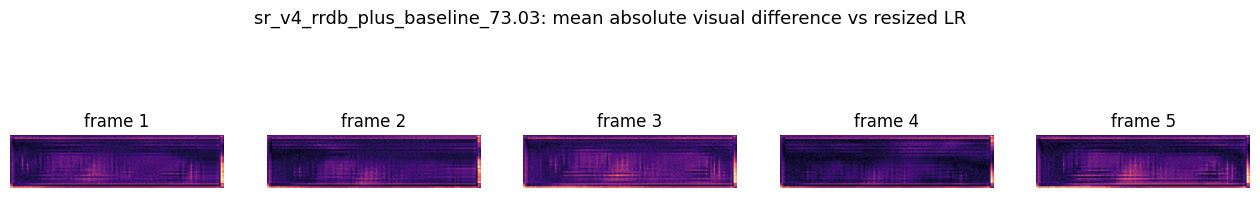

TRACK: track_15824
GT: BEW9H92


,checkpoint,prediction_csv,confidence_csv,ground_truth,correct_csv,note
0,baseline_no_sr_73.00,BEV9H92,0.9296,BEW9H92,0,"ResTranOCR baseline, no SR"
1,sr_v4_rrdb_plus_baseline_73.03,BEW9H92,0.9312,BEW9H92,1,RRDB from v4 + OCR baseline; best measured SR ...
2,sr_v4_joint_72.47,BEW9H92,0.9821,BEW9H92,1,Joint-trained RRDB + OCR from v4
3,sr_v7_feedhr_joint_62.23,BEW9H92,0.9971,BEW9H92,1,v7 feed-HR joint checkpoint; low test accuracy
4,sr_fix_e1_72.57,BEW9H92,0.9449,BEW9H92,1,1 epoch SR-only fine-tune from merged checkpoint


,checkpoint,live_prediction,live_confidence,ground_truth,live_correct,note
0,baseline_no_sr_73.00,BEV9H92,0.929618,BEW9H92,0,"ResTranOCR baseline, no SR"
1,sr_v4_rrdb_plus_baseline_73.03,BEW9H92,0.931209,BEW9H92,1,RRDB from v4 + OCR baseline; best measured SR ...
2,sr_v4_joint_72.47,BEW9H92,0.981995,BEW9H92,1,Joint-trained RRDB + OCR from v4
3,sr_v7_feedhr_joint_62.23,BEW9H92,0.997108,BEW9H92,1,v7 feed-HR joint checkpoint; low test accuracy
4,sr_fix_e1_72.57,BEW9H92,0.944881,BEW9H92,1,1 epoch SR-only fine-tune from merged checkpoint


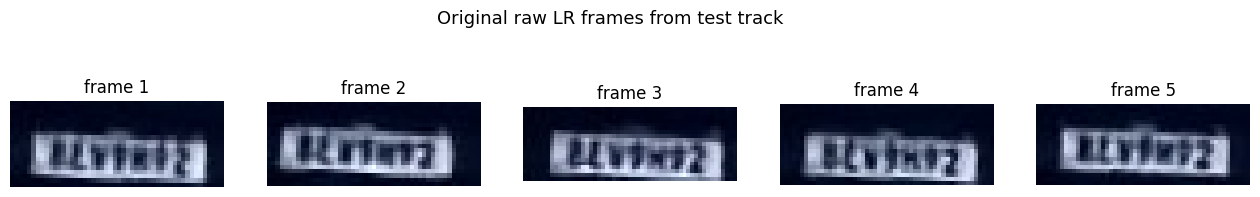

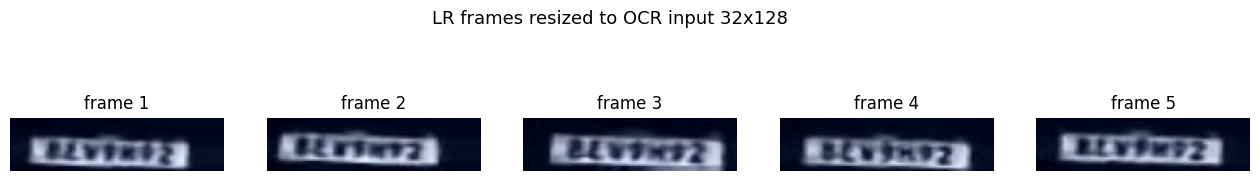

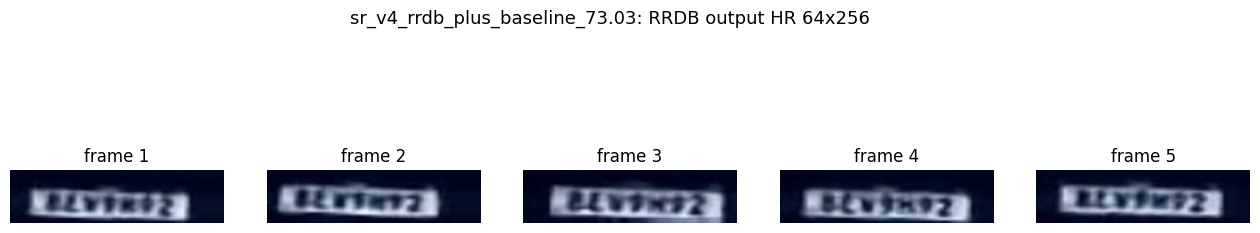

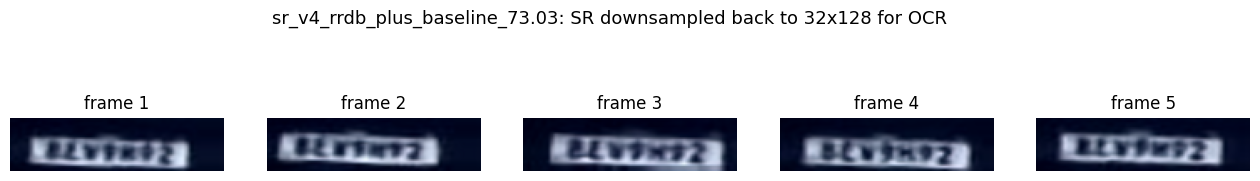

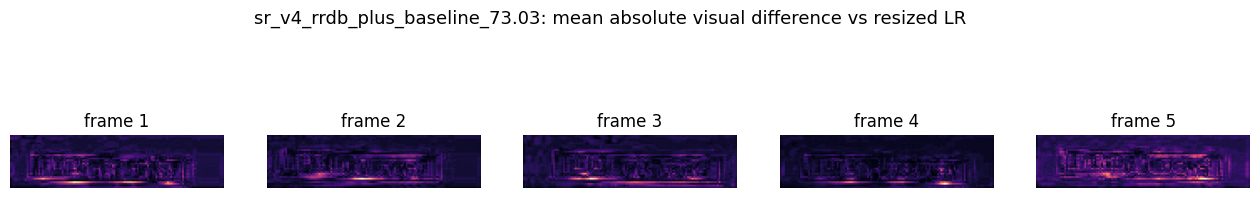

TRACK: track_12471
GT: ABL3656


,checkpoint,prediction_csv,confidence_csv,ground_truth,correct_csv,note
0,baseline_no_sr_73.00,ABL3658,0.8986,ABL3656,0,"ResTranOCR baseline, no SR"
1,sr_v4_rrdb_plus_baseline_73.03,ABL3656,0.8981,ABL3656,1,RRDB from v4 + OCR baseline; best measured SR ...
2,sr_v4_joint_72.47,ABL3656,0.9664,ABL3656,1,Joint-trained RRDB + OCR from v4
3,sr_v7_feedhr_joint_62.23,ABL3658,0.8923,ABL3656,0,v7 feed-HR joint checkpoint; low test accuracy
4,sr_fix_e1_72.57,ABL3656,0.9372,ABL3656,1,1 epoch SR-only fine-tune from merged checkpoint


,checkpoint,live_prediction,live_confidence,ground_truth,live_correct,note
0,baseline_no_sr_73.00,ABL3658,0.898522,ABL3656,0,"ResTranOCR baseline, no SR"
1,sr_v4_rrdb_plus_baseline_73.03,ABL3656,0.898180,ABL3656,1,RRDB from v4 + OCR baseline; best measured SR ...
2,sr_v4_joint_72.47,ABL3656,0.966398,ABL3656,1,Joint-trained RRDB + OCR from v4
3,sr_v7_feedhr_joint_62.23,ABL3658,0.892284,ABL3656,0,v7 feed-HR joint checkpoint; low test accuracy
4,sr_fix_e1_72.57,ABL3656,0.937328,ABL3656,1,1 epoch SR-only fine-tune from merged checkpoint


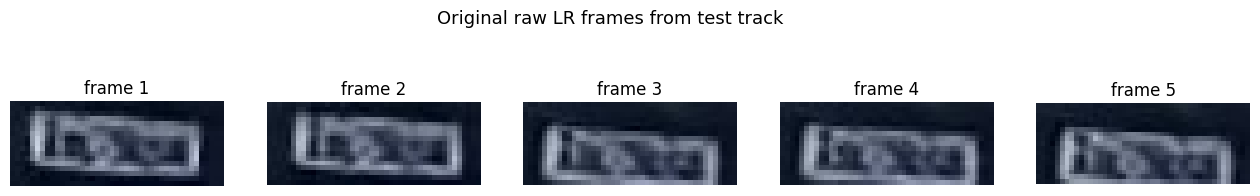

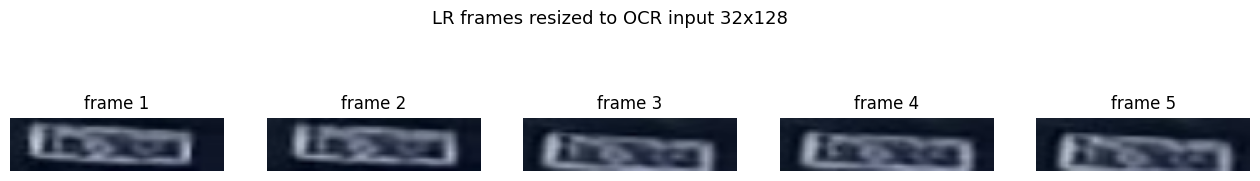

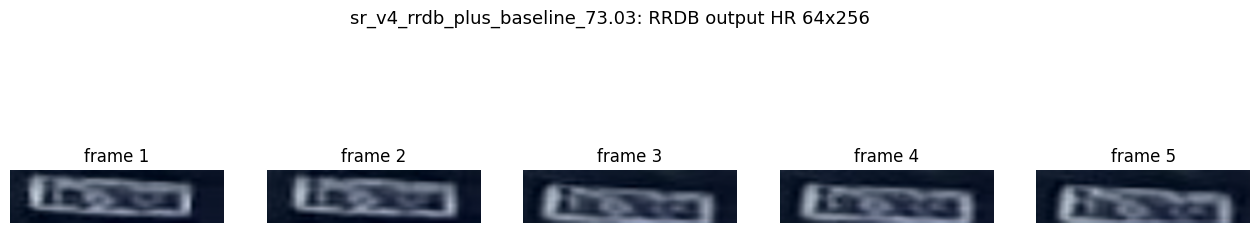

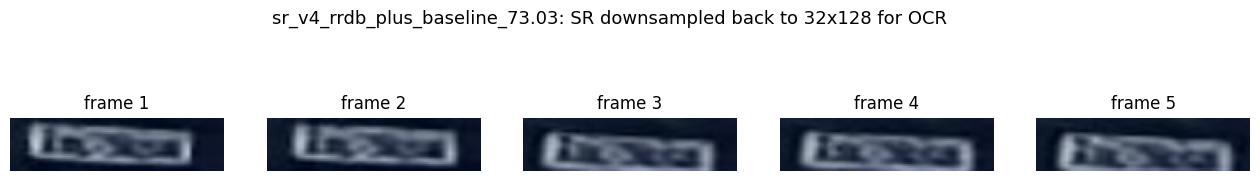

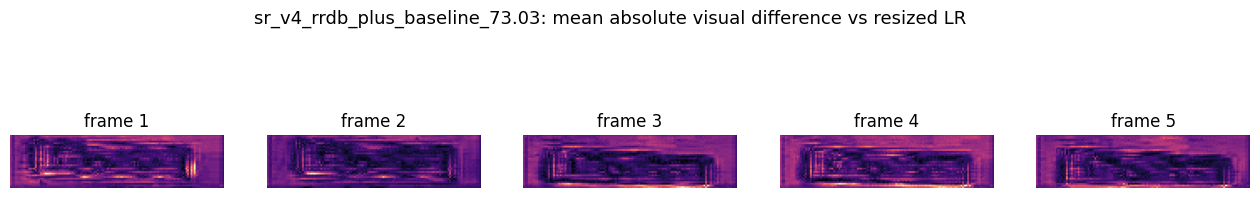

TRACK: track_19947
GT: PWB8I73


,checkpoint,prediction_csv,confidence_csv,ground_truth,correct_csv,note
0,baseline_no_sr_73.00,PVB8I73,0.9350,PWB8I73,0,"ResTranOCR baseline, no SR"
1,sr_v4_rrdb_plus_baseline_73.03,PWB8I73,0.9284,PWB8I73,1,RRDB from v4 + OCR baseline; best measured SR ...
2,sr_v4_joint_72.47,PWB8I73,0.9621,PWB8I73,1,Joint-trained RRDB + OCR from v4
3,sr_v7_feedhr_joint_62.23,PWB8I73,0.9927,PWB8I73,1,v7 feed-HR joint checkpoint; low test accuracy
4,sr_fix_e1_72.57,PWB8I73,0.9413,PWB8I73,1,1 epoch SR-only fine-tune from merged checkpoint


,checkpoint,live_prediction,live_confidence,ground_truth,live_correct,note
0,baseline_no_sr_73.00,PVB8I73,0.934995,PWB8I73,0,"ResTranOCR baseline, no SR"
1,sr_v4_rrdb_plus_baseline_73.03,PWB8I73,0.928416,PWB8I73,1,RRDB from v4 + OCR baseline; best measured SR ...
2,sr_v4_joint_72.47,PWB8I73,0.961837,PWB8I73,1,Joint-trained RRDB + OCR from v4
3,sr_v7_feedhr_joint_62.23,PWB8I73,0.992669,PWB8I73,1,v7 feed-HR joint checkpoint; low test accuracy
4,sr_fix_e1_72.57,PWB8I73,0.941360,PWB8I73,1,1 epoch SR-only fine-tune from merged checkpoint


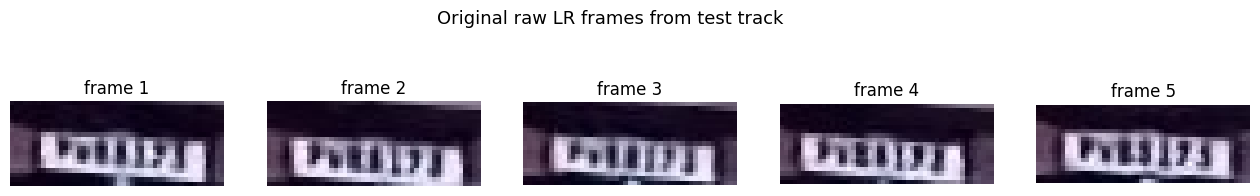

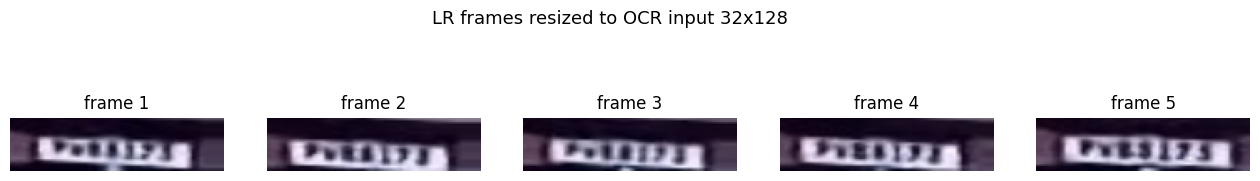

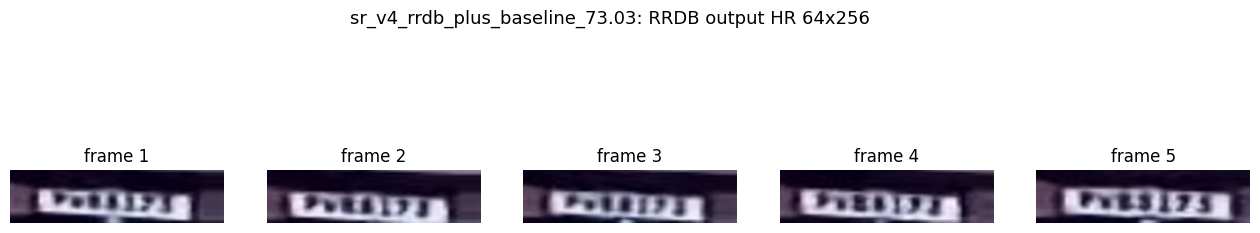

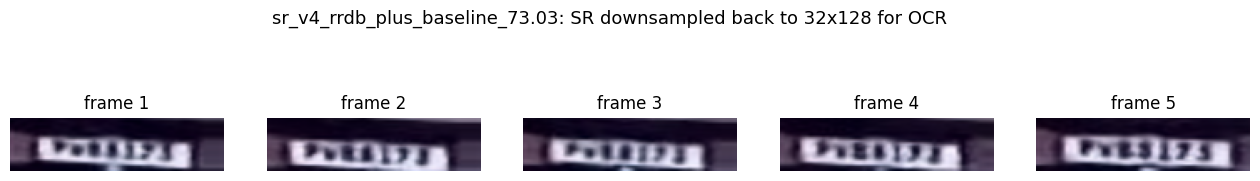

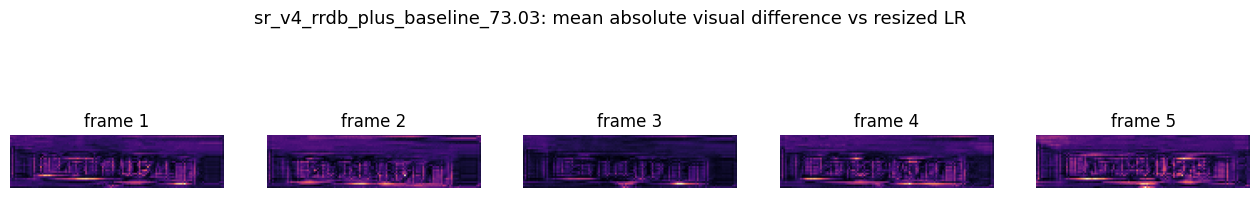

TRACK: track_21729
GT: SKY2B60


,checkpoint,prediction_csv,confidence_csv,ground_truth,correct_csv,note
0,baseline_no_sr_73.00,SKY2B68,0.9015,SKY2B60,0,"ResTranOCR baseline, no SR"
1,sr_v4_rrdb_plus_baseline_73.03,SKY2B60,0.9065,SKY2B60,1,RRDB from v4 + OCR baseline; best measured SR ...
2,sr_v4_joint_72.47,SKY2B60,0.9379,SKY2B60,1,Joint-trained RRDB + OCR from v4
3,sr_v7_feedhr_joint_62.23,SKY2B68,0.8863,SKY2B60,0,v7 feed-HR joint checkpoint; low test accuracy
4,sr_fix_e1_72.57,SKY2B60,0.9374,SKY2B60,1,1 epoch SR-only fine-tune from merged checkpoint


,checkpoint,live_prediction,live_confidence,ground_truth,live_correct,note
0,baseline_no_sr_73.00,SKY2B68,0.901673,SKY2B60,0,"ResTranOCR baseline, no SR"
1,sr_v4_rrdb_plus_baseline_73.03,SKY2B60,0.906485,SKY2B60,1,RRDB from v4 + OCR baseline; best measured SR ...
2,sr_v4_joint_72.47,SKY2B60,0.938180,SKY2B60,1,Joint-trained RRDB + OCR from v4
3,sr_v7_feedhr_joint_62.23,SKY2B68,0.886263,SKY2B60,0,v7 feed-HR joint checkpoint; low test accuracy
4,sr_fix_e1_72.57,SKY2B60,0.937307,SKY2B60,1,1 epoch SR-only fine-tune from merged checkpoint


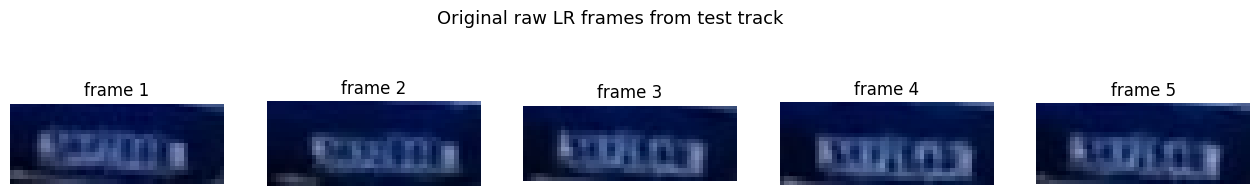

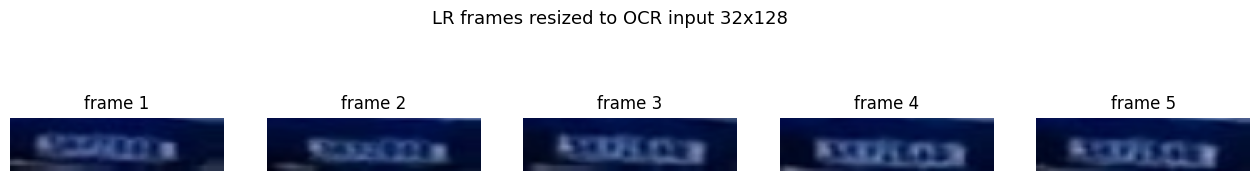

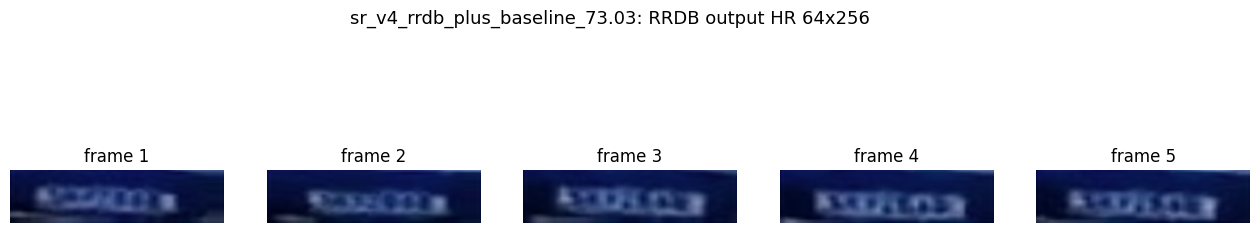

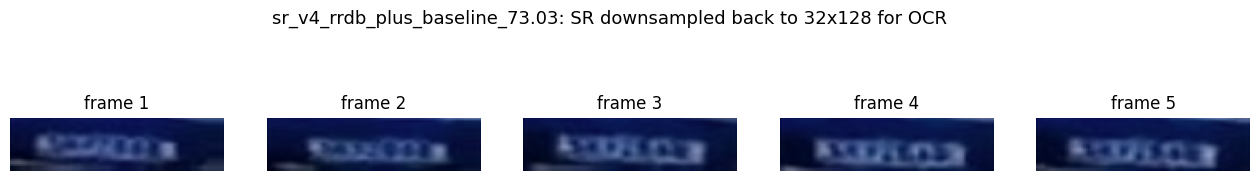

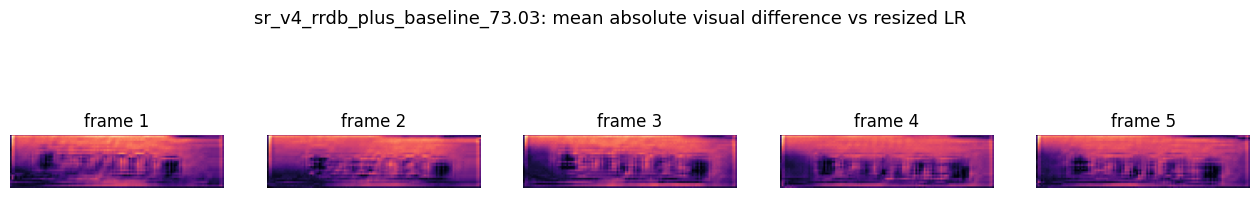

TRACK: track_21218
GT: QXU9A68


,checkpoint,prediction_csv,confidence_csv,ground_truth,correct_csv,note
0,baseline_no_sr_73.00,QXU9A68,0.8806,QXU9A68,1,"ResTranOCR baseline, no SR"
1,sr_v4_rrdb_plus_baseline_73.03,DXU9A68,0.8714,QXU9A68,0,RRDB from v4 + OCR baseline; best measured SR ...
2,sr_v4_joint_72.47,QXU9A68,0.9299,QXU9A68,1,Joint-trained RRDB + OCR from v4
3,sr_v7_feedhr_joint_62.23,QXU9A687,0.8093,QXU9A68,0,v7 feed-HR joint checkpoint; low test accuracy
4,sr_fix_e1_72.57,QXU9A68,0.8726,QXU9A68,1,1 epoch SR-only fine-tune from merged checkpoint


,checkpoint,live_prediction,live_confidence,ground_truth,live_correct,note
0,baseline_no_sr_73.00,QXU9A68,0.880600,QXU9A68,1,"ResTranOCR baseline, no SR"
1,sr_v4_rrdb_plus_baseline_73.03,DXU9A68,0.871518,QXU9A68,0,RRDB from v4 + OCR baseline; best measured SR ...
2,sr_v4_joint_72.47,QXU9A68,0.930030,QXU9A68,1,Joint-trained RRDB + OCR from v4
3,sr_v7_feedhr_joint_62.23,QXU9A687,0.809272,QXU9A68,0,v7 feed-HR joint checkpoint; low test accuracy
4,sr_fix_e1_72.57,QXU9A68,0.872648,QXU9A68,1,1 epoch SR-only fine-tune from merged checkpoint


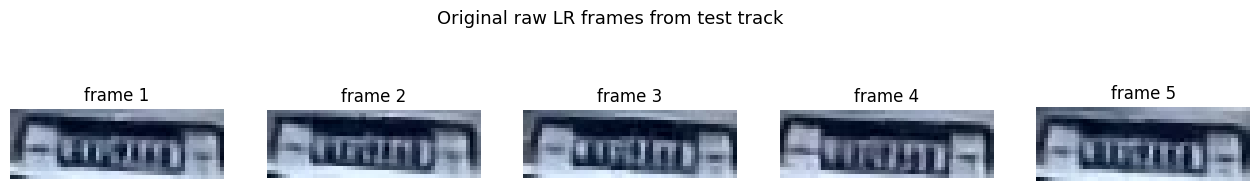

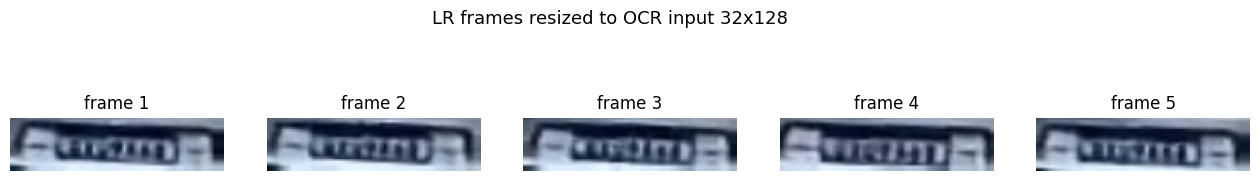

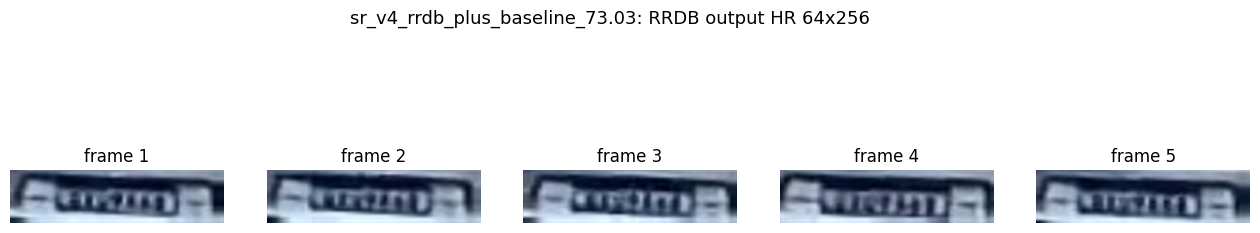

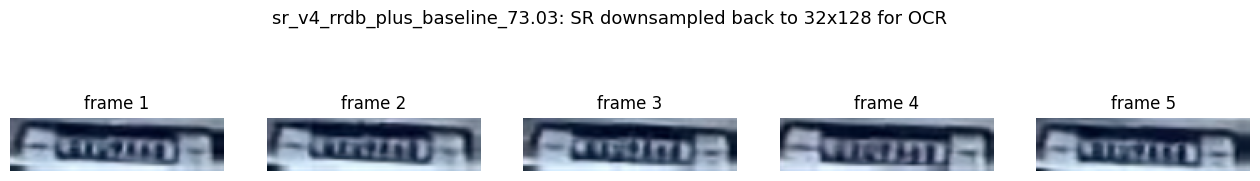

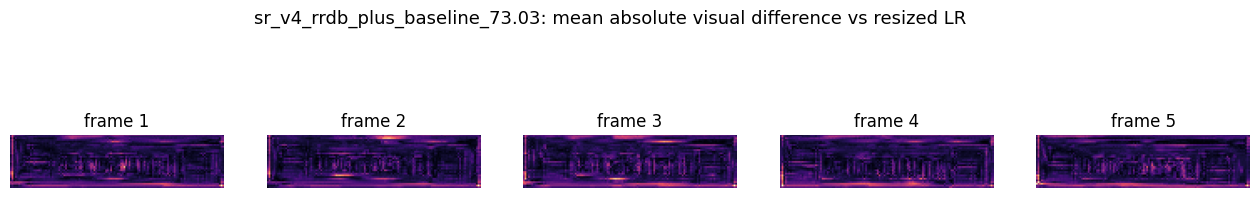

TRACK: track_19767
GT: AWJ0G14


,checkpoint,prediction_csv,confidence_csv,ground_truth,correct_csv,note
0,baseline_no_sr_73.00,AWJ0G14,0.9305,AWJ0G14,1,"ResTranOCR baseline, no SR"
1,sr_v4_rrdb_plus_baseline_73.03,AVJ0G14,0.9162,AWJ0G14,0,RRDB from v4 + OCR baseline; best measured SR ...
2,sr_v4_joint_72.47,AVJ0G14,0.8912,AWJ0G14,0,Joint-trained RRDB + OCR from v4
3,sr_v7_feedhr_joint_62.23,AWJ5G14,0.8471,AWJ0G14,0,v7 feed-HR joint checkpoint; low test accuracy
4,sr_fix_e1_72.57,AWJ0G14,0.9152,AWJ0G14,1,1 epoch SR-only fine-tune from merged checkpoint


,checkpoint,live_prediction,live_confidence,ground_truth,live_correct,note
0,baseline_no_sr_73.00,AWJ0G14,0.930465,AWJ0G14,1,"ResTranOCR baseline, no SR"
1,sr_v4_rrdb_plus_baseline_73.03,AVJ0G14,0.916166,AWJ0G14,0,RRDB from v4 + OCR baseline; best measured SR ...
2,sr_v4_joint_72.47,AVJ0G14,0.891077,AWJ0G14,0,Joint-trained RRDB + OCR from v4
3,sr_v7_feedhr_joint_62.23,AWJ5G14,0.847056,AWJ0G14,0,v7 feed-HR joint checkpoint; low test accuracy
4,sr_fix_e1_72.57,AWJ0G14,0.915220,AWJ0G14,1,1 epoch SR-only fine-tune from merged checkpoint


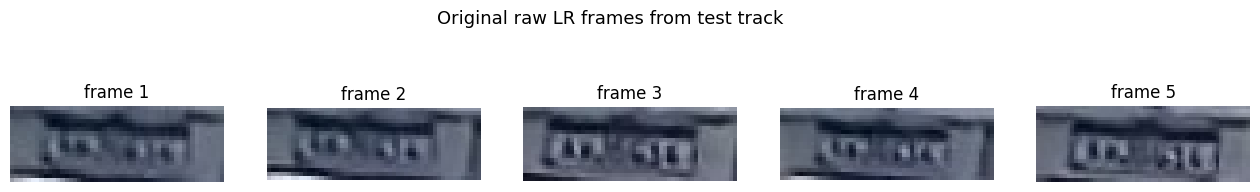

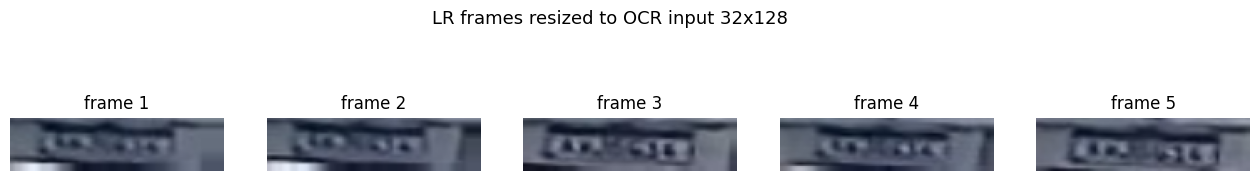

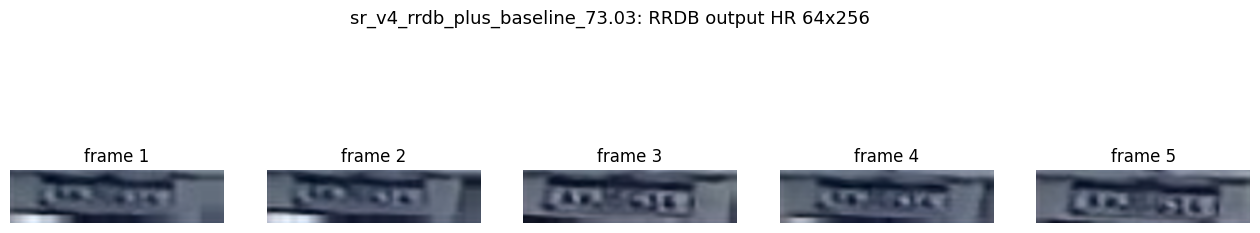

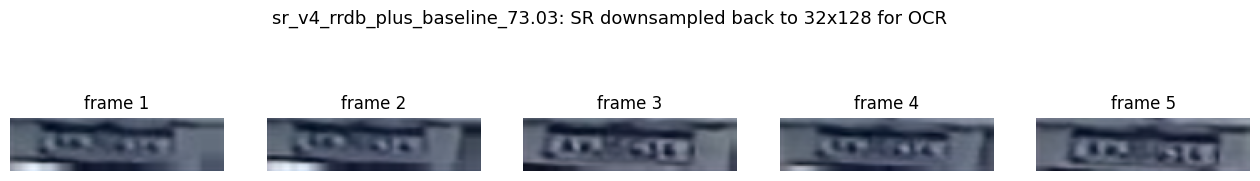

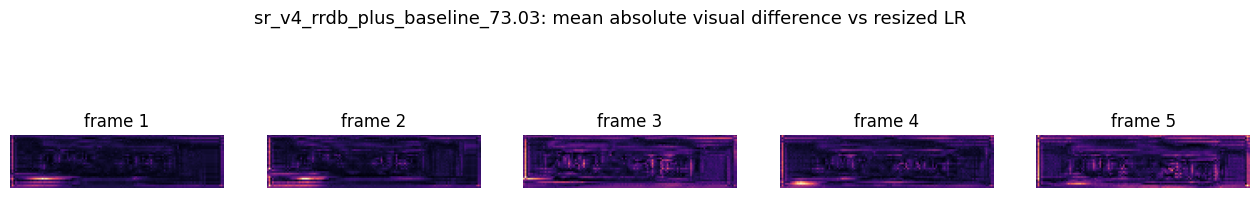

TRACK: track_16025
GT: SEM6C72


,checkpoint,prediction_csv,confidence_csv,ground_truth,correct_csv,note
0,baseline_no_sr_73.00,SEM6C72,0.9418,SEM6C72,1,"ResTranOCR baseline, no SR"
1,sr_v4_rrdb_plus_baseline_73.03,SEH6C72,0.9315,SEM6C72,0,RRDB from v4 + OCR baseline; best measured SR ...
2,sr_v4_joint_72.47,SEM6C72,0.9660,SEM6C72,1,Joint-trained RRDB + OCR from v4
3,sr_v7_feedhr_joint_62.23,SEM6C72,0.9821,SEM6C72,1,v7 feed-HR joint checkpoint; low test accuracy
4,sr_fix_e1_72.57,SEH6C72,0.9314,SEM6C72,0,1 epoch SR-only fine-tune from merged checkpoint


,checkpoint,live_prediction,live_confidence,ground_truth,live_correct,note
0,baseline_no_sr_73.00,SEM6C72,0.941767,SEM6C72,1,"ResTranOCR baseline, no SR"
1,sr_v4_rrdb_plus_baseline_73.03,SEH6C72,0.931461,SEM6C72,0,RRDB from v4 + OCR baseline; best measured SR ...
2,sr_v4_joint_72.47,SEM6C72,0.966091,SEM6C72,1,Joint-trained RRDB + OCR from v4
3,sr_v7_feedhr_joint_62.23,SEM6C72,0.982132,SEM6C72,1,v7 feed-HR joint checkpoint; low test accuracy
4,sr_fix_e1_72.57,SEH6C72,0.931395,SEM6C72,0,1 epoch SR-only fine-tune from merged checkpoint


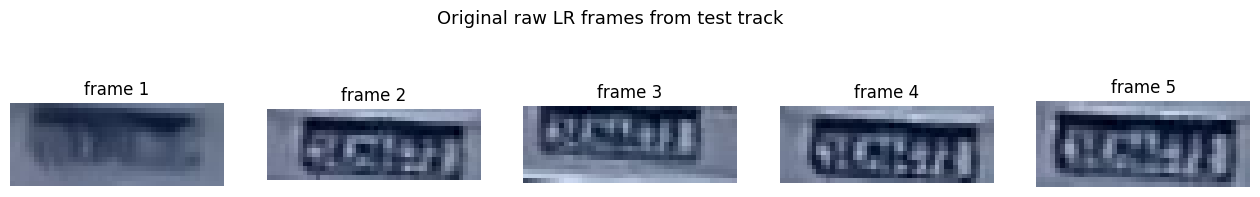

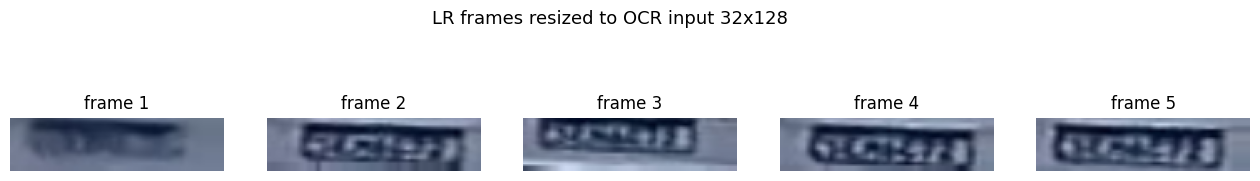

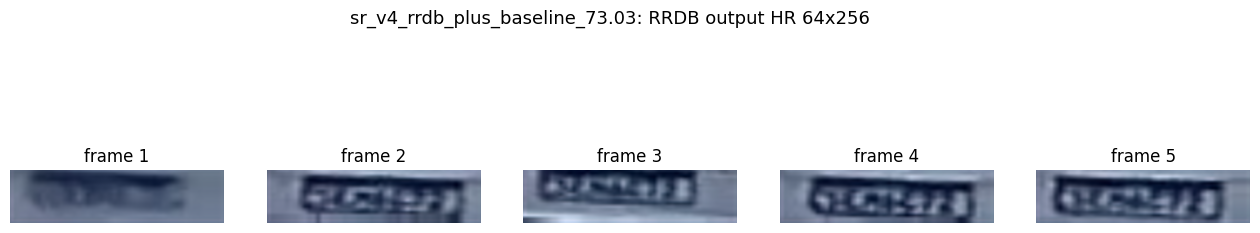

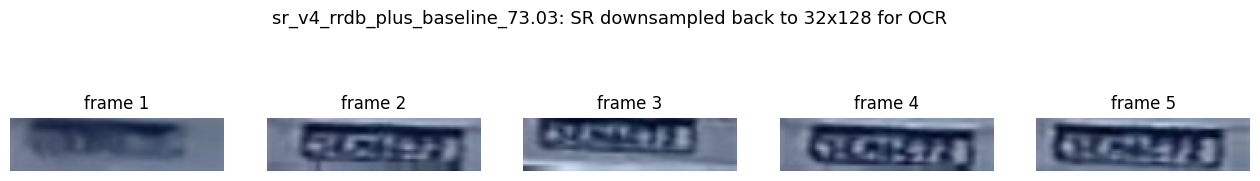

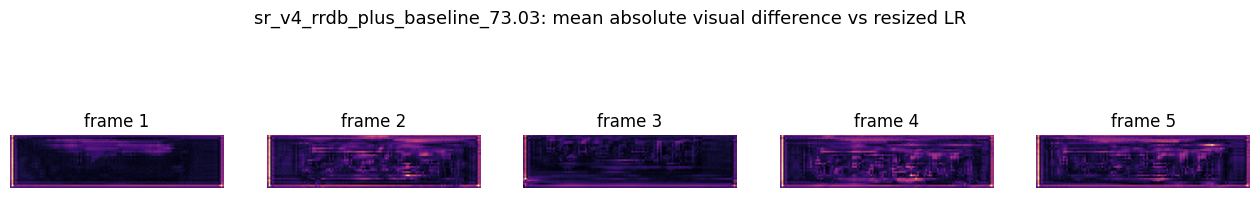

TRACK: track_22671
GT: BCE2J06


,checkpoint,prediction_csv,confidence_csv,ground_truth,correct_csv,note
0,baseline_no_sr_73.00,BCE2J06,0.8794,BCE2J06,1,"ResTranOCR baseline, no SR"
1,sr_v4_rrdb_plus_baseline_73.03,BCK2J06,0.8812,BCE2J06,0,RRDB from v4 + OCR baseline; best measured SR ...
2,sr_v4_joint_72.47,BCK2J06,0.8759,BCE2J06,0,Joint-trained RRDB + OCR from v4
3,sr_v7_feedhr_joint_62.23,BCE2J56,0.7591,BCE2J06,0,v7 feed-HR joint checkpoint; low test accuracy
4,sr_fix_e1_72.57,BCK2J06,0.8603,BCE2J06,0,1 epoch SR-only fine-tune from merged checkpoint


,checkpoint,live_prediction,live_confidence,ground_truth,live_correct,note
0,baseline_no_sr_73.00,BCE2J06,0.879328,BCE2J06,1,"ResTranOCR baseline, no SR"
1,sr_v4_rrdb_plus_baseline_73.03,BCK2J06,0.881311,BCE2J06,0,RRDB from v4 + OCR baseline; best measured SR ...
2,sr_v4_joint_72.47,BCK2J06,0.876087,BCE2J06,0,Joint-trained RRDB + OCR from v4
3,sr_v7_feedhr_joint_62.23,BCE2J56,0.759022,BCE2J06,0,v7 feed-HR joint checkpoint; low test accuracy
4,sr_fix_e1_72.57,BCK2J06,0.860371,BCE2J06,0,1 epoch SR-only fine-tune from merged checkpoint


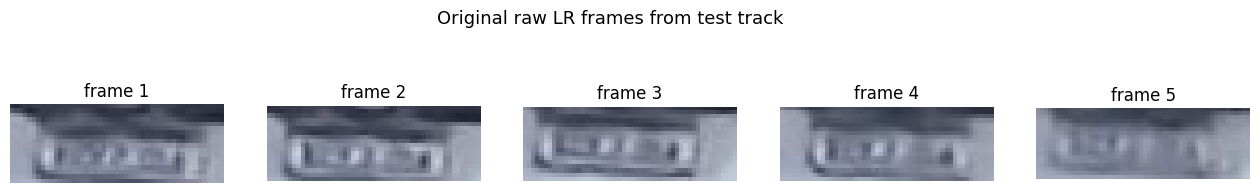

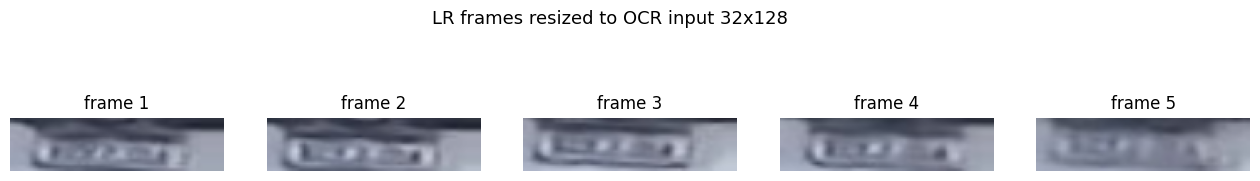

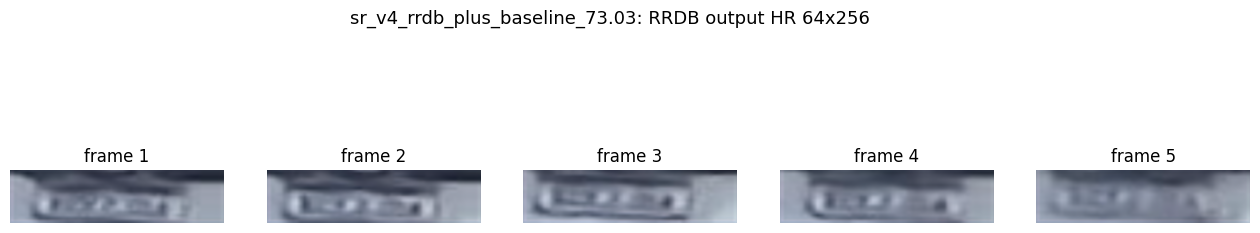

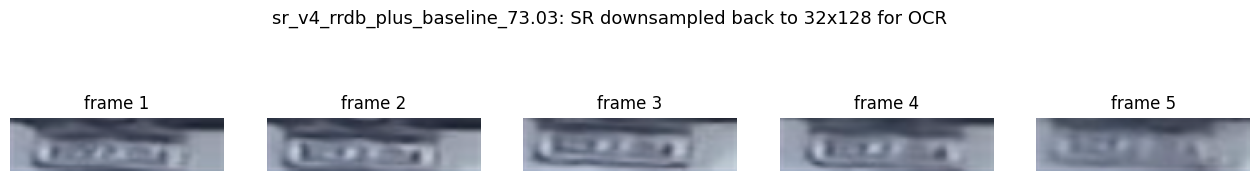

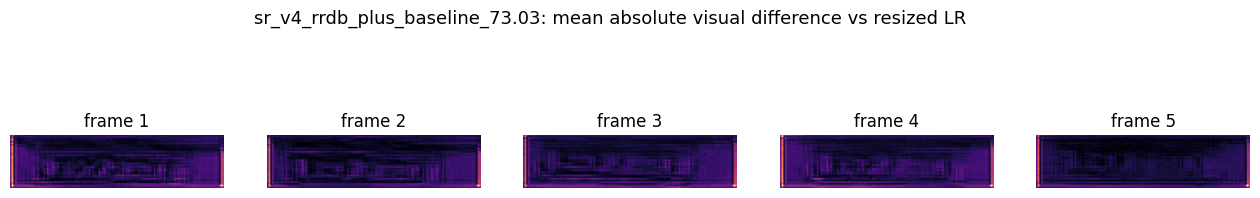

TRACK: track_10598
GT: BAL0730


,checkpoint,prediction_csv,confidence_csv,ground_truth,correct_csv,note
0,baseline_no_sr_73.00,BAL0730,0.9473,BAL0730,1,"ResTranOCR baseline, no SR"
1,sr_v4_rrdb_plus_baseline_73.03,BAL0730,0.9416,BAL0730,1,RRDB from v4 + OCR baseline; best measured SR ...
2,sr_v4_joint_72.47,BAL0730,0.9777,BAL0730,1,Joint-trained RRDB + OCR from v4
3,sr_v7_feedhr_joint_62.23,BAL0738,0.8881,BAL0730,0,v7 feed-HR joint checkpoint; low test accuracy
4,sr_fix_e1_72.57,BAL0730,0.9427,BAL0730,1,1 epoch SR-only fine-tune from merged checkpoint


,checkpoint,live_prediction,live_confidence,ground_truth,live_correct,note
0,baseline_no_sr_73.00,BAL0730,0.947214,BAL0730,1,"ResTranOCR baseline, no SR"
1,sr_v4_rrdb_plus_baseline_73.03,BAL0730,0.941630,BAL0730,1,RRDB from v4 + OCR baseline; best measured SR ...
2,sr_v4_joint_72.47,BAL0730,0.977628,BAL0730,1,Joint-trained RRDB + OCR from v4
3,sr_v7_feedhr_joint_62.23,BAL0738,0.888091,BAL0730,0,v7 feed-HR joint checkpoint; low test accuracy
4,sr_fix_e1_72.57,BAL0730,0.942650,BAL0730,1,1 epoch SR-only fine-tune from merged checkpoint


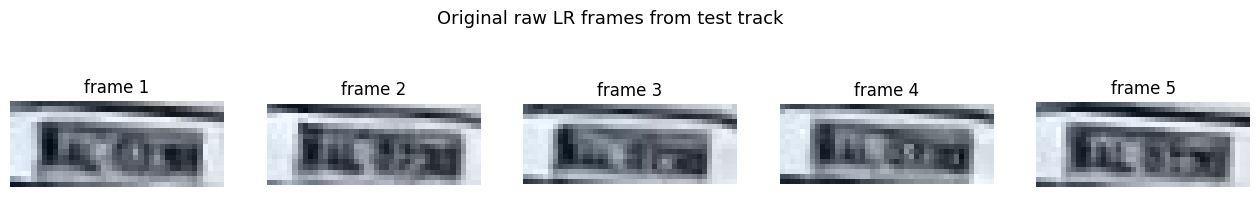

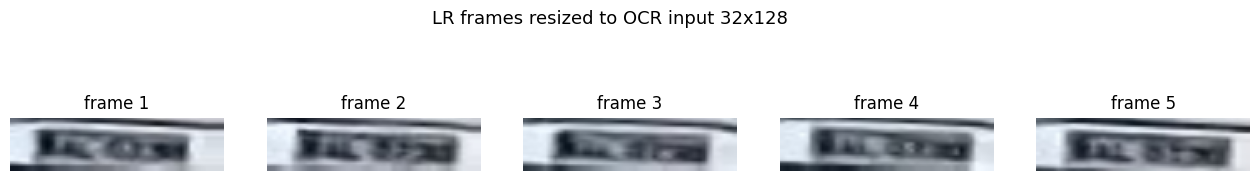

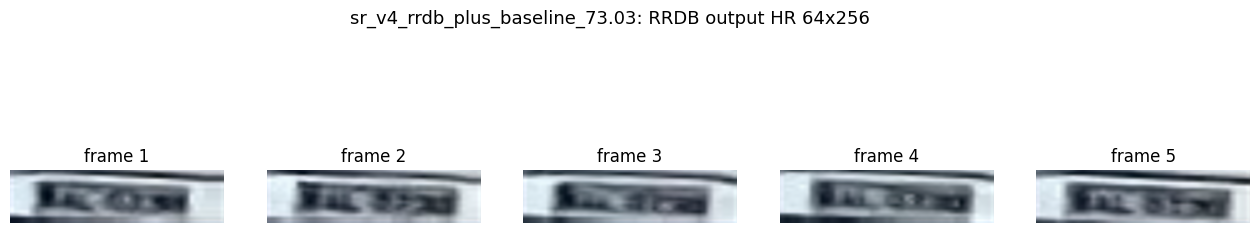

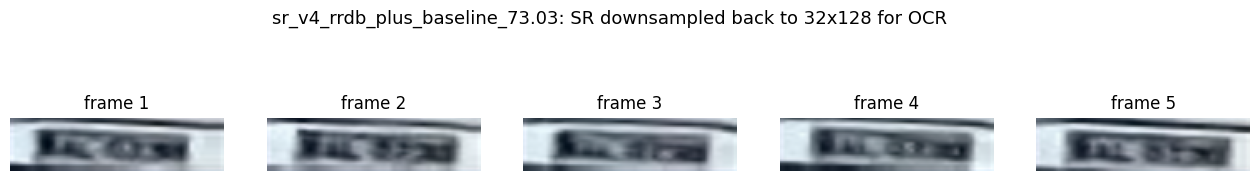

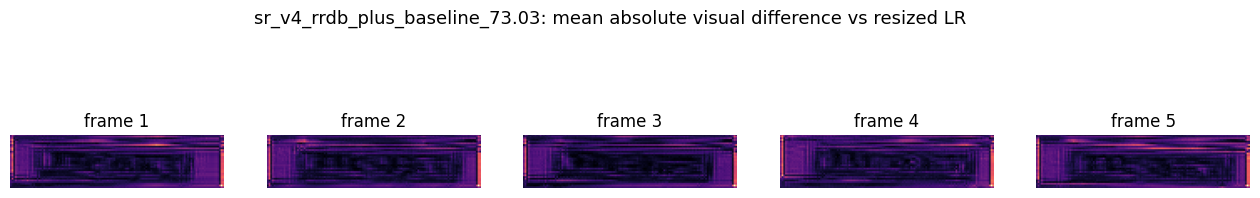

TRACK: track_10768
GT: QHL1343


,checkpoint,prediction_csv,confidence_csv,ground_truth,correct_csv,note
0,baseline_no_sr_73.00,QHL1343,0.9751,QHL1343,1,"ResTranOCR baseline, no SR"
1,sr_v4_rrdb_plus_baseline_73.03,QHL1343,0.9719,QHL1343,1,RRDB from v4 + OCR baseline; best measured SR ...
2,sr_v4_joint_72.47,QHL1343,0.9909,QHL1343,1,Joint-trained RRDB + OCR from v4
3,sr_v7_feedhr_joint_62.23,OML1343,0.8486,QHL1343,0,v7 feed-HR joint checkpoint; low test accuracy
4,sr_fix_e1_72.57,QHL1343,0.9836,QHL1343,1,1 epoch SR-only fine-tune from merged checkpoint


,checkpoint,live_prediction,live_confidence,ground_truth,live_correct,note
0,baseline_no_sr_73.00,QHL1343,0.975058,QHL1343,1,"ResTranOCR baseline, no SR"
1,sr_v4_rrdb_plus_baseline_73.03,QHL1343,0.971900,QHL1343,1,RRDB from v4 + OCR baseline; best measured SR ...
2,sr_v4_joint_72.47,QHL1343,0.990909,QHL1343,1,Joint-trained RRDB + OCR from v4
3,sr_v7_feedhr_joint_62.23,OML1343,0.848590,QHL1343,0,v7 feed-HR joint checkpoint; low test accuracy
4,sr_fix_e1_72.57,QHL1343,0.983533,QHL1343,1,1 epoch SR-only fine-tune from merged checkpoint


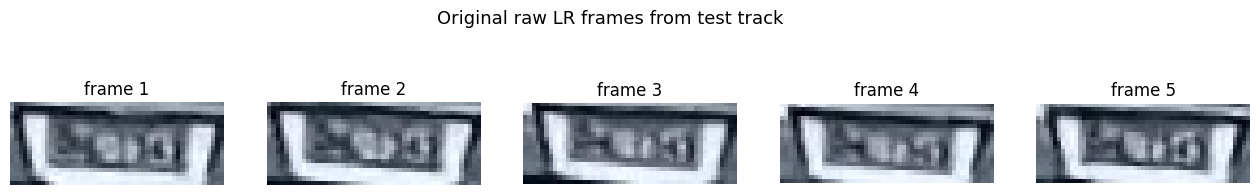

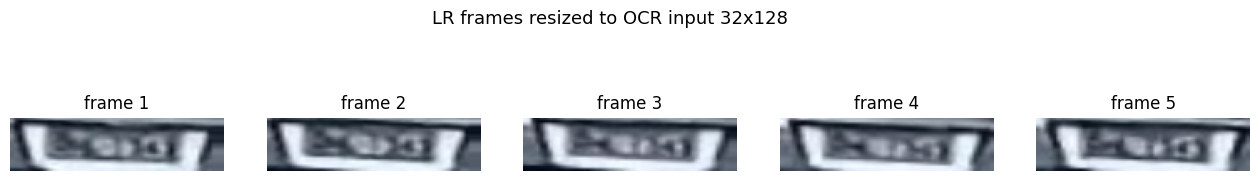

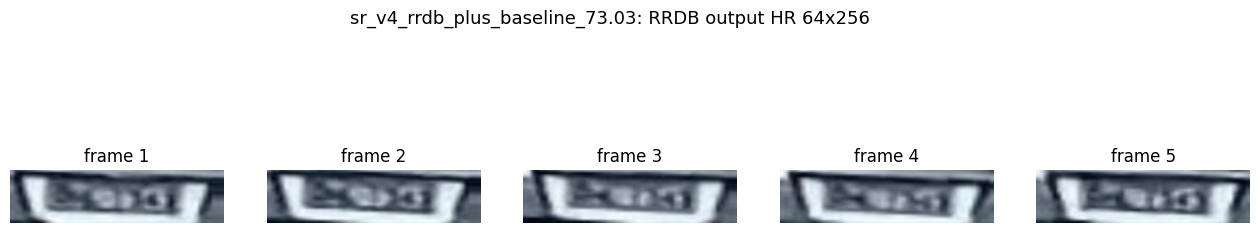

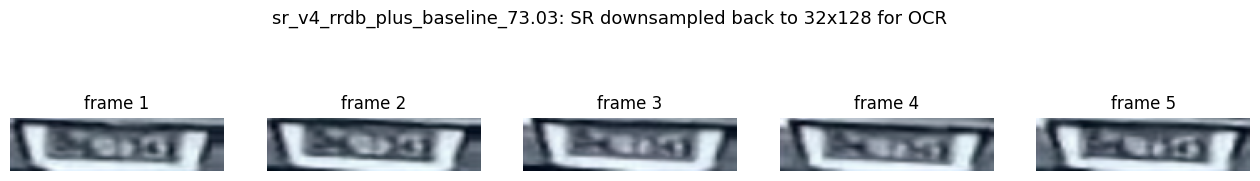

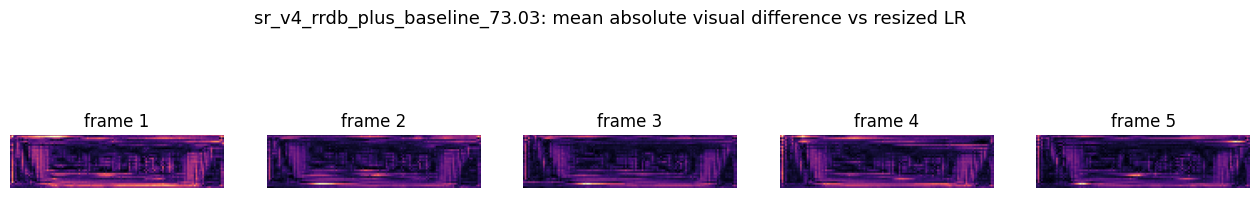

TRACK: track_15149
GT: QQC0D18


,checkpoint,prediction_csv,confidence_csv,ground_truth,correct_csv,note
0,baseline_no_sr_73.00,QQC0D18,0.9971,QQC0D18,1,"ResTranOCR baseline, no SR"
1,sr_v4_rrdb_plus_baseline_73.03,QQC0D18,0.9973,QQC0D18,1,RRDB from v4 + OCR baseline; best measured SR ...
2,sr_v4_joint_72.47,QQC0D18,0.9975,QQC0D18,1,Joint-trained RRDB + OCR from v4
3,sr_v7_feedhr_joint_62.23,QQC0B18,0.9784,QQC0D18,0,v7 feed-HR joint checkpoint; low test accuracy
4,sr_fix_e1_72.57,QQC0D18,0.9974,QQC0D18,1,1 epoch SR-only fine-tune from merged checkpoint


,checkpoint,live_prediction,live_confidence,ground_truth,live_correct,note
0,baseline_no_sr_73.00,QQC0D18,0.997147,QQC0D18,1,"ResTranOCR baseline, no SR"
1,sr_v4_rrdb_plus_baseline_73.03,QQC0D18,0.997258,QQC0D18,1,RRDB from v4 + OCR baseline; best measured SR ...
2,sr_v4_joint_72.47,QQC0D18,0.997506,QQC0D18,1,Joint-trained RRDB + OCR from v4
3,sr_v7_feedhr_joint_62.23,QQC0B18,0.978378,QQC0D18,0,v7 feed-HR joint checkpoint; low test accuracy
4,sr_fix_e1_72.57,QQC0D18,0.997411,QQC0D18,1,1 epoch SR-only fine-tune from merged checkpoint


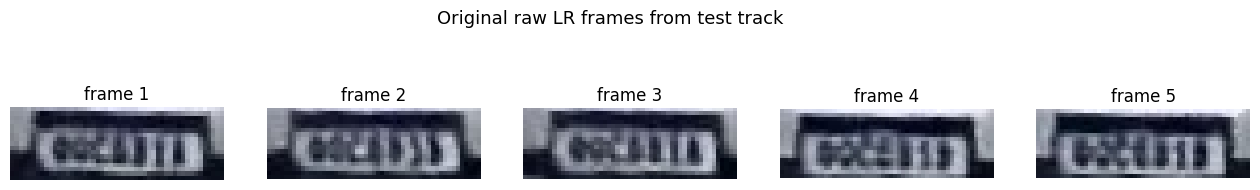

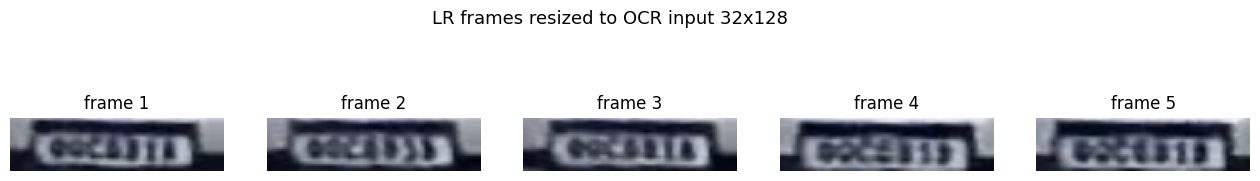

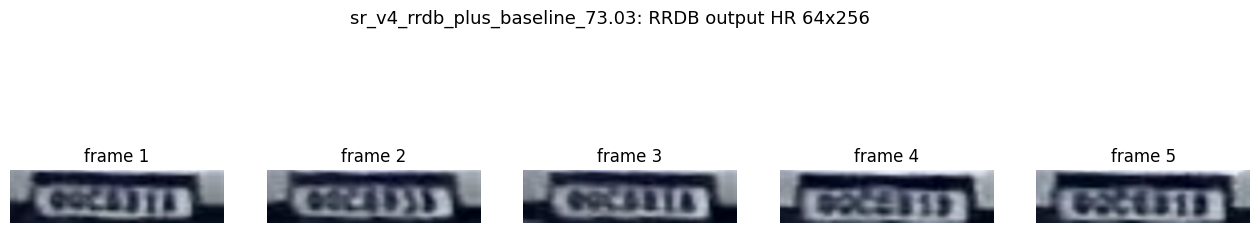

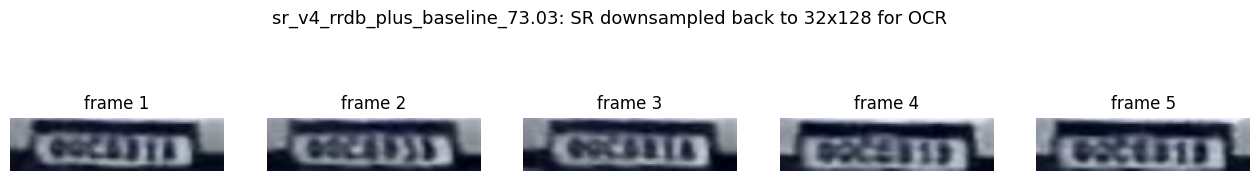

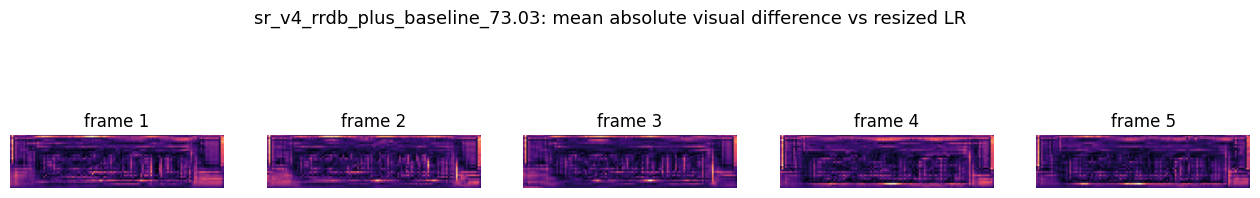

TRACK: track_18599
GT: SNU7G52


,checkpoint,prediction_csv,confidence_csv,ground_truth,correct_csv,note
0,baseline_no_sr_73.00,SNU7G52,0.9858,SNU7G52,1,"ResTranOCR baseline, no SR"
1,sr_v4_rrdb_plus_baseline_73.03,SNU7G52,0.9922,SNU7G52,1,RRDB from v4 + OCR baseline; best measured SR ...
2,sr_v4_joint_72.47,SNU7G52,0.9854,SNU7G52,1,Joint-trained RRDB + OCR from v4
3,sr_v7_feedhr_joint_62.23,SWU7G52,0.9397,SNU7G52,0,v7 feed-HR joint checkpoint; low test accuracy
4,sr_fix_e1_72.57,SNU7G52,0.9936,SNU7G52,1,1 epoch SR-only fine-tune from merged checkpoint


,checkpoint,live_prediction,live_confidence,ground_truth,live_correct,note
0,baseline_no_sr_73.00,SNU7G52,0.985857,SNU7G52,1,"ResTranOCR baseline, no SR"
1,sr_v4_rrdb_plus_baseline_73.03,SNU7G52,0.992180,SNU7G52,1,RRDB from v4 + OCR baseline; best measured SR ...
2,sr_v4_joint_72.47,SNU7G52,0.985303,SNU7G52,1,Joint-trained RRDB + OCR from v4
3,sr_v7_feedhr_joint_62.23,SWU7G52,0.939564,SNU7G52,0,v7 feed-HR joint checkpoint; low test accuracy
4,sr_fix_e1_72.57,SNU7G52,0.993628,SNU7G52,1,1 epoch SR-only fine-tune from merged checkpoint


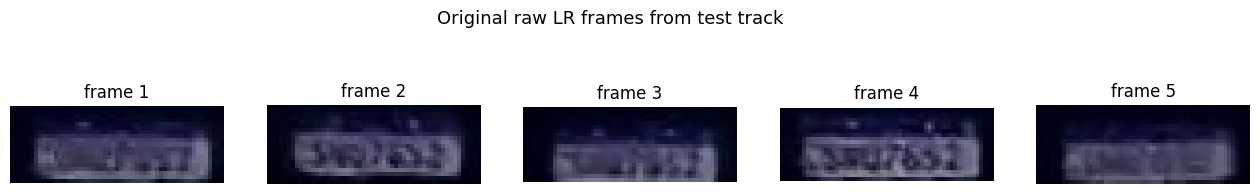

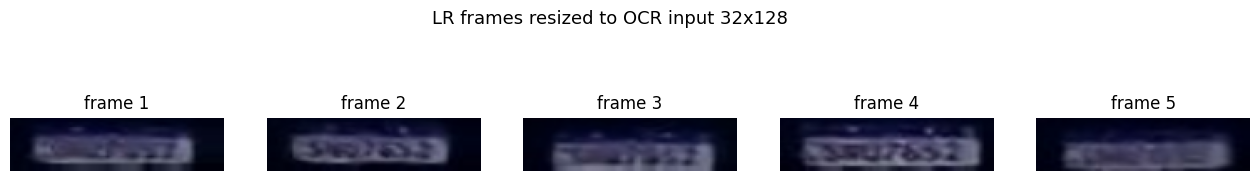

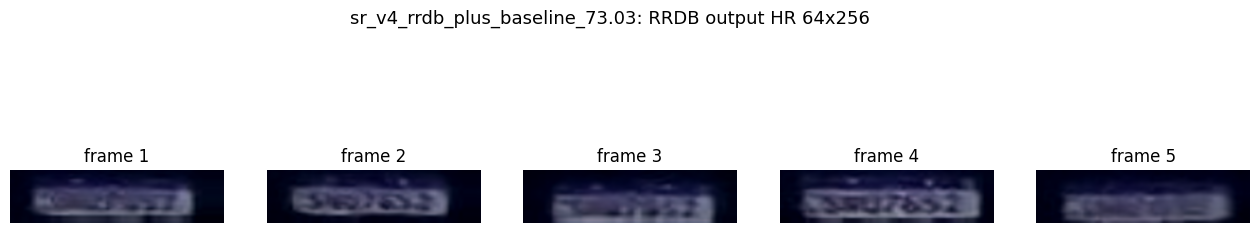

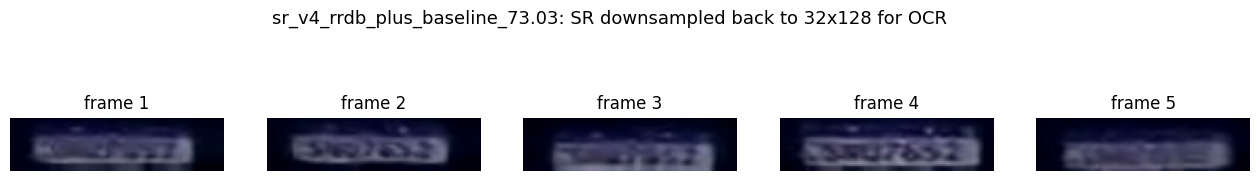

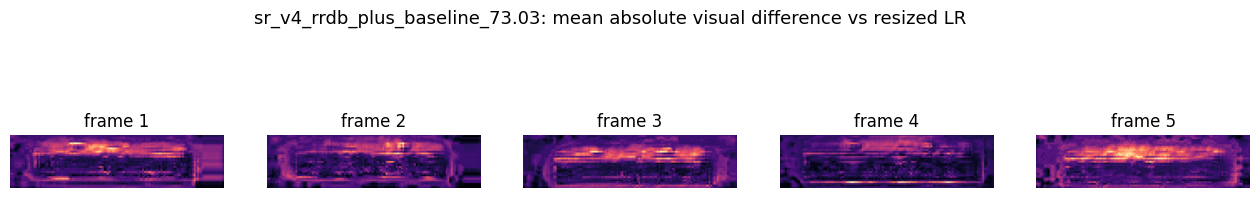

TRACK: track_20634
GT: BCV5D34


,checkpoint,prediction_csv,confidence_csv,ground_truth,correct_csv,note
0,baseline_no_sr_73.00,BCV5D34,0.9992,BCV5D34,1,"ResTranOCR baseline, no SR"
1,sr_v4_rrdb_plus_baseline_73.03,BCV5D34,0.9993,BCV5D34,1,RRDB from v4 + OCR baseline; best measured SR ...
2,sr_v4_joint_72.47,BCV5D34,0.9988,BCV5D34,1,Joint-trained RRDB + OCR from v4
3,sr_v7_feedhr_joint_62.23,BCV5D34,0.9964,BCV5D34,1,v7 feed-HR joint checkpoint; low test accuracy
4,sr_fix_e1_72.57,BCV5D34,0.9992,BCV5D34,1,1 epoch SR-only fine-tune from merged checkpoint


,checkpoint,live_prediction,live_confidence,ground_truth,live_correct,note
0,baseline_no_sr_73.00,BCV5D34,0.999233,BCV5D34,1,"ResTranOCR baseline, no SR"
1,sr_v4_rrdb_plus_baseline_73.03,BCV5D34,0.999254,BCV5D34,1,RRDB from v4 + OCR baseline; best measured SR ...
2,sr_v4_joint_72.47,BCV5D34,0.998795,BCV5D34,1,Joint-trained RRDB + OCR from v4
3,sr_v7_feedhr_joint_62.23,BCV5D34,0.996383,BCV5D34,1,v7 feed-HR joint checkpoint; low test accuracy
4,sr_fix_e1_72.57,BCV5D34,0.999219,BCV5D34,1,1 epoch SR-only fine-tune from merged checkpoint


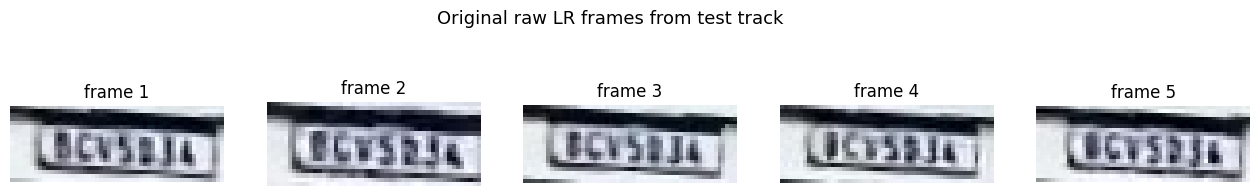

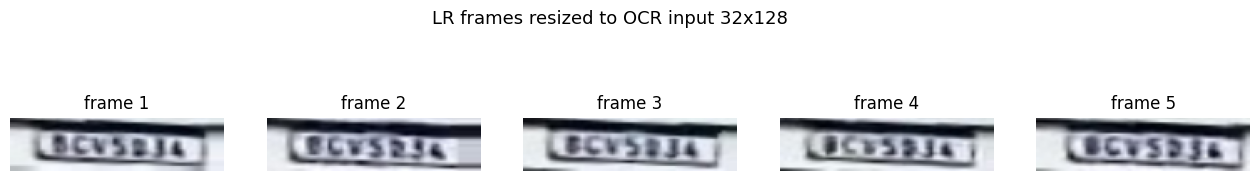

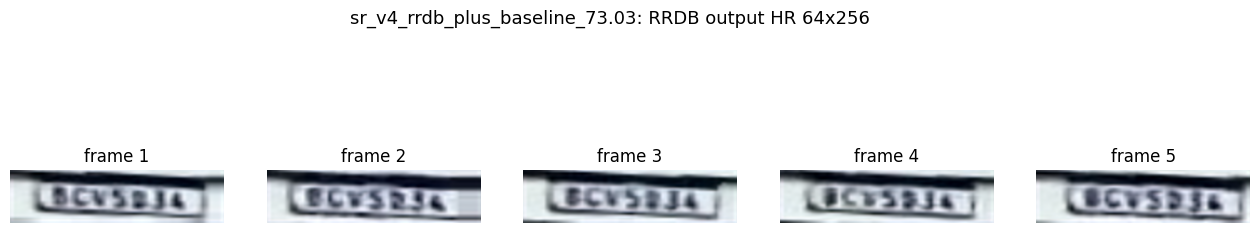

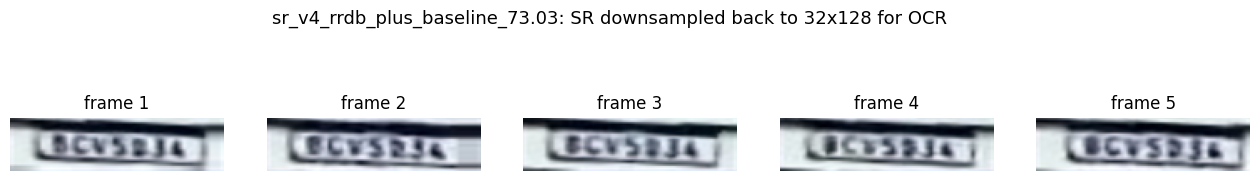

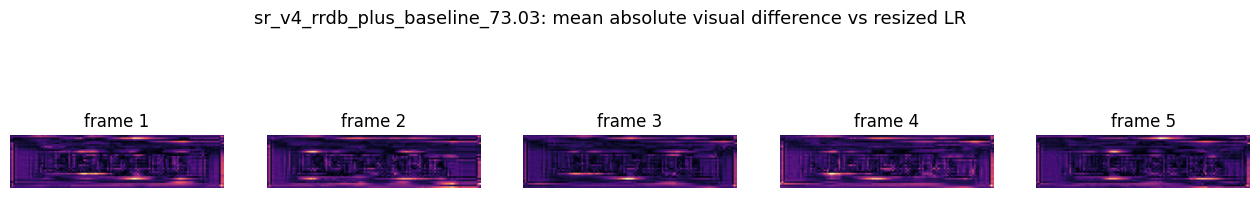

TRACK: track_14544
GT: AYP5I57


,checkpoint,prediction_csv,confidence_csv,ground_truth,correct_csv,note
0,baseline_no_sr_73.00,AYP5I57,0.9994,AYP5I57,1,"ResTranOCR baseline, no SR"
1,sr_v4_rrdb_plus_baseline_73.03,AYP5I57,0.9994,AYP5I57,1,RRDB from v4 + OCR baseline; best measured SR ...
2,sr_v4_joint_72.47,AYP5I57,0.9992,AYP5I57,1,Joint-trained RRDB + OCR from v4
3,sr_v7_feedhr_joint_62.23,AYP5I57,0.9012,AYP5I57,1,v7 feed-HR joint checkpoint; low test accuracy
4,sr_fix_e1_72.57,AYP5I57,0.9993,AYP5I57,1,1 epoch SR-only fine-tune from merged checkpoint


,checkpoint,live_prediction,live_confidence,ground_truth,live_correct,note
0,baseline_no_sr_73.00,AYP5I57,0.999409,AYP5I57,1,"ResTranOCR baseline, no SR"
1,sr_v4_rrdb_plus_baseline_73.03,AYP5I57,0.999361,AYP5I57,1,RRDB from v4 + OCR baseline; best measured SR ...
2,sr_v4_joint_72.47,AYP5I57,0.999170,AYP5I57,1,Joint-trained RRDB + OCR from v4
3,sr_v7_feedhr_joint_62.23,AYP5I57,0.901223,AYP5I57,1,v7 feed-HR joint checkpoint; low test accuracy
4,sr_fix_e1_72.57,AYP5I57,0.999292,AYP5I57,1,1 epoch SR-only fine-tune from merged checkpoint


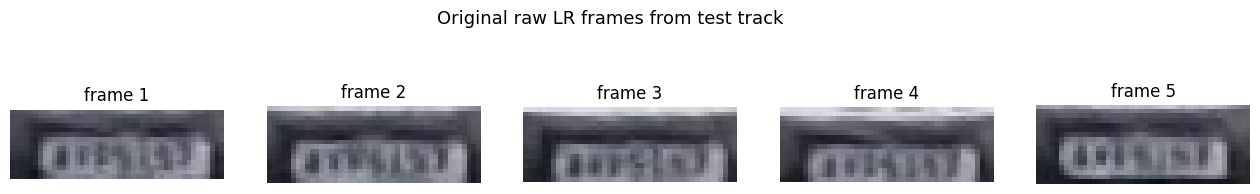

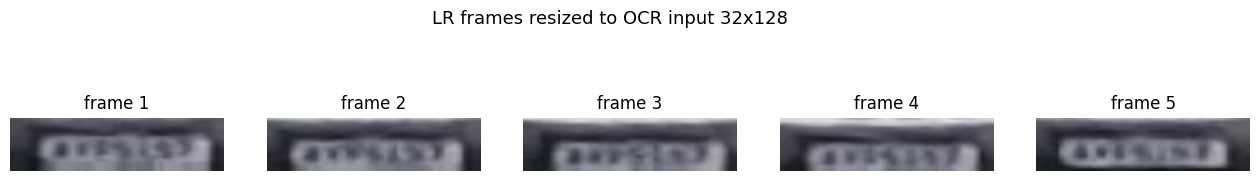

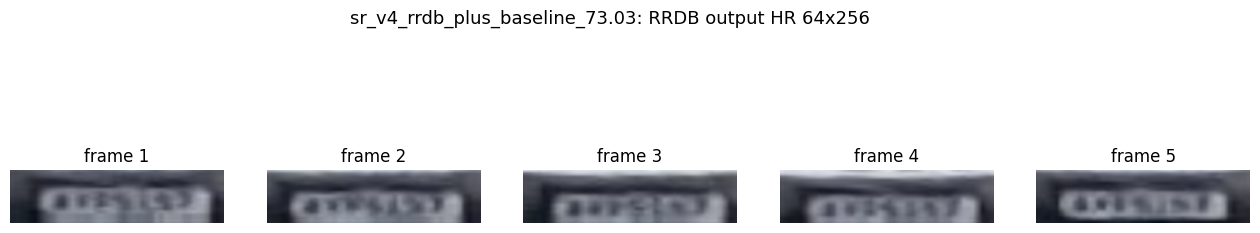

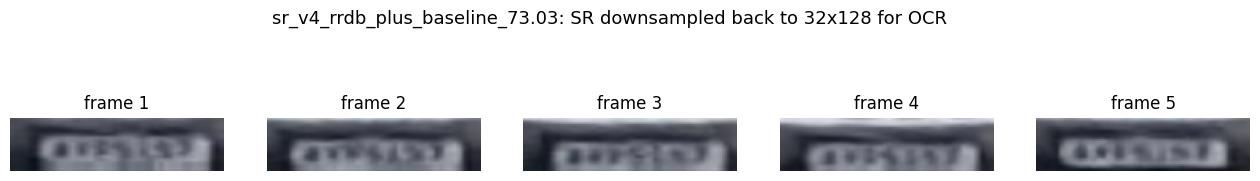

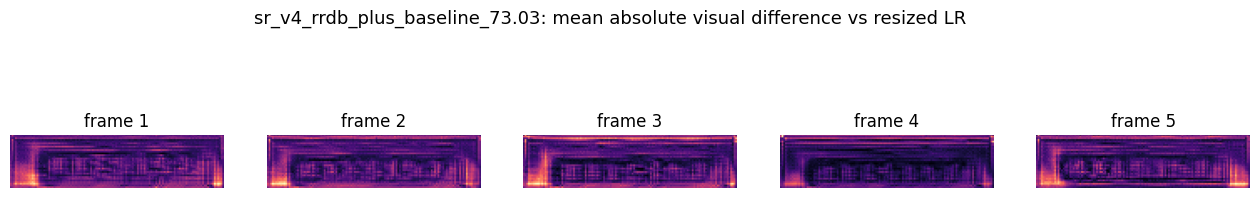

TRACK: track_16720
GT: SEZ0E81


,checkpoint,prediction_csv,confidence_csv,ground_truth,correct_csv,note
0,baseline_no_sr_73.00,SEZ0E81,0.9600,SEZ0E81,1,"ResTranOCR baseline, no SR"
1,sr_v4_rrdb_plus_baseline_73.03,SEZ0E81,0.9634,SEZ0E81,1,RRDB from v4 + OCR baseline; best measured SR ...
2,sr_v4_joint_72.47,SEI0E81,0.9429,SEZ0E81,0,Joint-trained RRDB + OCR from v4
3,sr_v7_feedhr_joint_62.23,SEZ0E81,0.8654,SEZ0E81,1,v7 feed-HR joint checkpoint; low test accuracy
4,sr_fix_e1_72.57,SEZ0E81,0.9615,SEZ0E81,1,1 epoch SR-only fine-tune from merged checkpoint


,checkpoint,live_prediction,live_confidence,ground_truth,live_correct,note
0,baseline_no_sr_73.00,SEZ0E81,0.960006,SEZ0E81,1,"ResTranOCR baseline, no SR"
1,sr_v4_rrdb_plus_baseline_73.03,SEZ0E81,0.963399,SEZ0E81,1,RRDB from v4 + OCR baseline; best measured SR ...
2,sr_v4_joint_72.47,SEI0E81,0.942728,SEZ0E81,0,Joint-trained RRDB + OCR from v4
3,sr_v7_feedhr_joint_62.23,SEZ0E81,0.865341,SEZ0E81,1,v7 feed-HR joint checkpoint; low test accuracy
4,sr_fix_e1_72.57,SEZ0E81,0.961426,SEZ0E81,1,1 epoch SR-only fine-tune from merged checkpoint


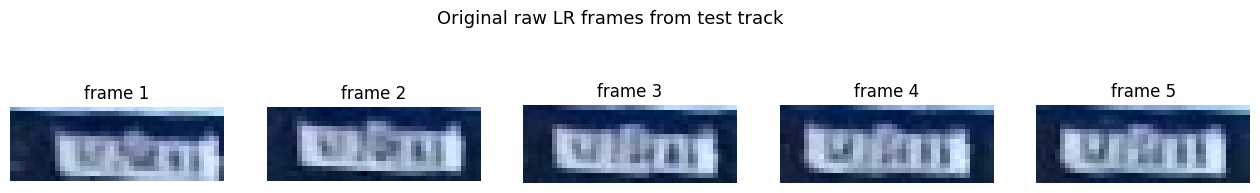

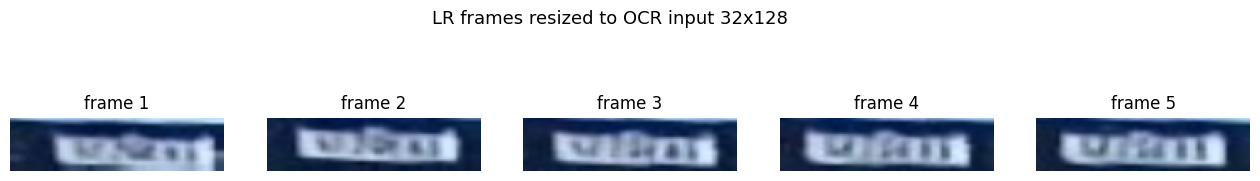

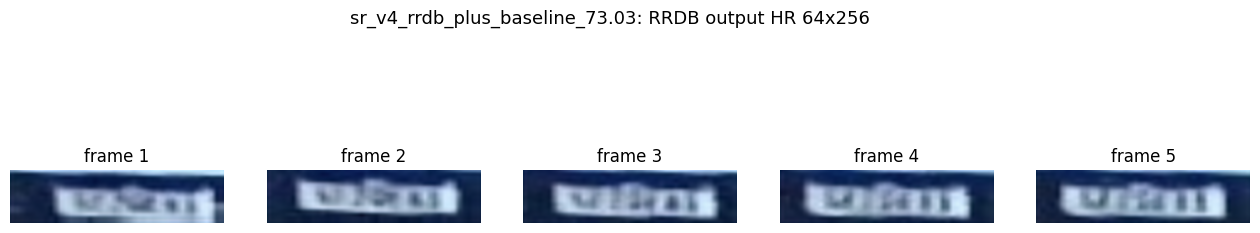

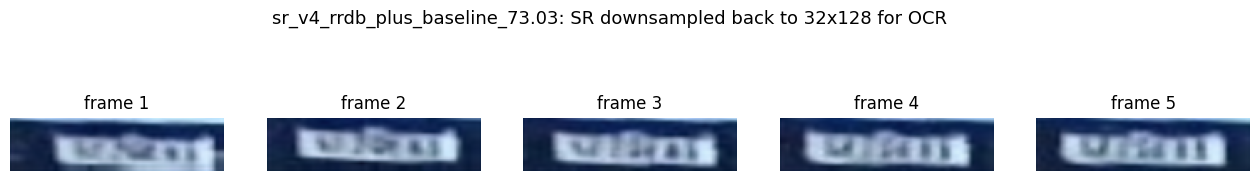

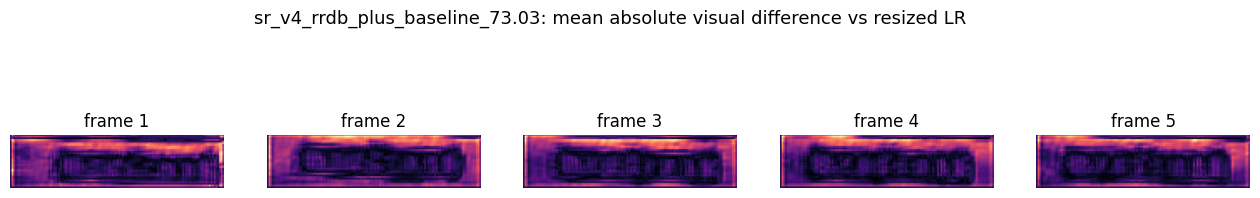

In [9]:
print("Selected tracks:", selected_ids)
for track_id in selected_ids[:16]:
    visualize_track(track_id)

## 6. Inspect one specific track and all RRDB checkpoints

In [ ]:
# Track ban dang chon trong CSV v7:
visualize_track("track_10119", show_all_rrdb=True)

In [ ]:
# Chi so sanh anh SR/RRDB cua tat ca checkpoint, khong lap lai raw/prediction table.
visualize_rrdb_grid("track_10119")

## 7. Optional: save visual panels to disk

Cell nay luu panel cua tung track vao `results/visual_debug/`.
Moi panel gom LR + HR RRDB + SR-downsample cua tat ca SR checkpoint.

In [ ]:
SAVE_DIR = Path("results/visual_debug")
SAVE_DIR.mkdir(parents=True, exist_ok=True)


def save_contact_sheet(track_id, sr_model_names=None):
    sr_model_names = sr_model_names or SR_MODEL_NAMES
    raw = load_raw_frames(track_id)
    x, resized_lr = preprocess_frames(raw)
    gt = read_label(track_path(track_id))
    pred_df = prediction_table(track_id)

    rows = OrderedDict()
    rows["LR 32x128"] = resized_lr
    for name in sr_model_names:
        visuals = rrdb_visuals(name, x)
        if visuals is None:
            continue
        rows[f"{name} HR"] = [(img * 255).astype(np.uint8) for img in visuals["sr_hr"]]
        rows[f"{name} down"] = [(img * 255).astype(np.uint8) for img in visuals["sr_down_for_ocr"]]

    n_rows = len(rows)
    fig, axes = plt.subplots(n_rows, NUM_FRAMES, figsize=(18, 2.8 * n_rows))
    if n_rows == 1:
        axes = np.expand_dims(axes, 0)
    fig.suptitle(f"{track_id} | GT={gt}", fontsize=14)
    for r, (label, row_imgs) in enumerate(rows.items()):
        for c, img in enumerate(row_imgs):
            axes[r, c].imshow(img)
            axes[r, c].set_title(f"{label}\nf{c + 1}", fontsize=8)
            axes[r, c].axis("off")
    fig.tight_layout()
    out = SAVE_DIR / f"{track_id}.png"
    fig.savefig(out, dpi=160, bbox_inches="tight")
    plt.close(fig)

    pred_df.to_csv(SAVE_DIR / f"{track_id}_predictions.csv", index=False)
    return out


saved = [save_contact_sheet(t) for t in selected_ids[:16]]
saved